# Antalya Otelleri: Cluster Bazlı N-HiTS

Bu notebook rezervasyonları check-in dahil, check-out hariç aylık inhouse occupied nights serilerine dönüştürür. Oteller 2022-2024 profilleriyle kümelenir; her cluster için global bir N-HiTS modeli eğitilir ve 2026 Ocak-Temmuz döneminde seasonal-naive benchmark'a karşı değerlendirilir.

2027 tahmini yalnızca önceden tanımlanan başarı kapısı sağlanırsa üretilir.

In [2]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import lightning.pytorch as pl

from sklearn.cluster import KMeans
from sklearn.metrics import (
    davies_bouldin_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.models import NHiTS
from pytorch_forecasting.metrics import MAE

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pl.seed_everything(42, workers=True)

RANDOM_STATE = 42
TRAIN_START = pd.Timestamp("2022-01-01")
TRAIN_END = pd.Timestamp("2025-12-01")
TEST_START = pd.Timestamp("2026-01-01")
TEST_END = pd.Timestamp("2026-07-01")
HORIZON = 7
INPUT_SIZE = 24
SUCCESS_WMAPE = 40.0
SUCCESS_R2 = 0.30

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "complete_cleaned_data_full.csv"
OUTPUT_DIR = PROJECT_ROOT / "output_nhits"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"PyTorch {torch.__version__}; accelerator={'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"Veri: {DATA_PATH}")
print(f"Çıktı: {OUTPUT_DIR}")

Seed set to 42


PyTorch 2.13.0+cpu; accelerator=cpu
Veri: c:\Users\efe.turhan\Desktop\sales_forecasting\data\complete_cleaned_data_full.csv
Çıktı: c:\Users\efe.turhan\Desktop\sales_forecasting\output_nhits


## 1. Aylık inhouse dönüşümü

Her benzersiz rezervasyon ay sınırlarında bölünür. Bir aya katkı, check-in dahil ve check-out hariç o ayda kalınan gece sayısıdır. Eksik otel-ay kombinasyonları sıfırla tamamlanır.

In [4]:
USE_COLUMNS = [
    "voucher_id", "sehir_adi", "hotel_id", "hotel_name",
    "voucher_checkin_date", "voucher_checout_date",
]

raw = pd.read_csv(
    DATA_PATH,
    sep=";",
    encoding="utf-8-sig",
    usecols=USE_COLUMNS,
    low_memory=False,
)
raw = raw.loc[
    raw["sehir_adi"].astype("string").str.strip().str.casefold().eq("antalya")
].drop_duplicates("voucher_id").copy()
raw["checkin"] = pd.to_datetime(raw["voucher_checkin_date"], errors="coerce").dt.normalize()
raw["checkout"] = pd.to_datetime(raw["voucher_checout_date"], errors="coerce").dt.normalize()
raw = raw.dropna(subset=["hotel_id", "checkin", "checkout"])
raw = raw.loc[
    raw["checkout"].gt(raw["checkin"])
    & raw["checkin"].lt(TEST_END + pd.offsets.MonthBegin(1))
    & raw["checkout"].gt(TRAIN_START)
].copy()
raw["stay_start"] = raw["checkin"].clip(lower=TRAIN_START)
raw["stay_end"] = raw["checkout"].clip(upper=TEST_END + pd.offsets.MonthBegin(1))
raw["start_month"] = raw["stay_start"].dt.to_period("M")
raw["end_month"] = (raw["stay_end"] - pd.Timedelta(days=1)).dt.to_period("M")
raw["month_count"] = (
    (raw["end_month"].dt.year - raw["start_month"].dt.year) * 12
    + raw["end_month"].dt.month
    - raw["start_month"].dt.month
    + 1
).astype(int)

expanded = raw.loc[
    raw.index.repeat(raw["month_count"]),
    ["hotel_id", "hotel_name", "stay_start", "stay_end", "start_month"],
].copy()
expanded["month_offset"] = expanded.groupby(level=0).cumcount()
month_number = (
    expanded["start_month"].dt.year * 12
    + expanded["start_month"].dt.month - 1
    + expanded["month_offset"]
)
expanded["ds"] = pd.to_datetime({
    "year": month_number // 12,
    "month": month_number % 12 + 1,
    "day": 1,
})
expanded["overlap_start"] = expanded[["stay_start", "ds"]].max(axis=1)
expanded["next_month"] = expanded["ds"] + pd.offsets.MonthBegin(1)
expanded["overlap_end"] = expanded[["stay_end", "next_month"]].min(axis=1)
expanded["occupied_nights"] = (expanded["overlap_end"] - expanded["overlap_start"]).dt.days

monthly_observed = expanded.groupby(["hotel_id", "ds"], as_index=False)["occupied_nights"].sum()
hotel_lookup = (
    raw.dropna(subset=["hotel_name"])
    .groupby("hotel_id")["hotel_name"]
    .agg(lambda values: values.mode().iat[0] if not values.mode().empty else values.iloc[0])
)
hotel_ids = pd.Index(sorted(monthly_observed["hotel_id"].unique()), name="hotel_id")
all_months = pd.date_range(TRAIN_START, TEST_END, freq="MS", name="ds")
monthly = (
    monthly_observed.set_index(["hotel_id", "ds"])
    .reindex(pd.MultiIndex.from_product([hotel_ids, all_months]), fill_value=0)
    .reset_index()
)
monthly["occupied_nights"] = monthly["occupied_nights"].astype(float)
monthly["hotel_name"] = monthly["hotel_id"].map(hotel_lookup).fillna(monthly["hotel_id"].astype(str))
monthly["unique_id"] = monthly["hotel_id"].astype(str)
monthly = monthly.sort_values(["hotel_id", "ds"]).reset_index(drop=True)
monthly.to_csv(OUTPUT_DIR / "monthly_hotel_inhouse.csv", index=False, encoding="utf-8-sig")

print({
    "valid_reservations": len(raw),
    "hotel_count": monthly["hotel_id"].nunique(),
    "panel_rows": len(monthly),
    "total_occupied_nights": int(monthly["occupied_nights"].sum()),
    "date_range": [str(monthly["ds"].min().date()), str(monthly["ds"].max().date())],
})
display(monthly.head())

{'valid_reservations': 122059, 'hotel_count': 807, 'panel_rows': 44385, 'total_occupied_nights': 522356, 'date_range': ['2022-01-01', '2026-07-01']}


,hotel_id,ds,occupied_nights,hotel_name,unique_id
0,371,2022-01-01,0.0,Ela Excellence Resort Belek,371
1,371,2022-02-01,0.0,Ela Excellence Resort Belek,371
2,371,2022-03-01,0.0,Ela Excellence Resort Belek,371
3,371,2022-04-01,2.0,Ela Excellence Resort Belek,371
4,371,2022-05-01,36.0,Ela Excellence Resort Belek,371


## 2. Leakage'sız otel clustering

Cluster merkezleri yalnızca 2022-2024 verisiyle öğrenilir. Ortalama 12 aylık normalize profil ile hacim, peak ve sezon yapısı eşit ağırlıklı iki blok halinde standardize edilir. Düşük sinyalli oteller merkez öğrenimine alınmaz fakat en yakın merkeze atanır.

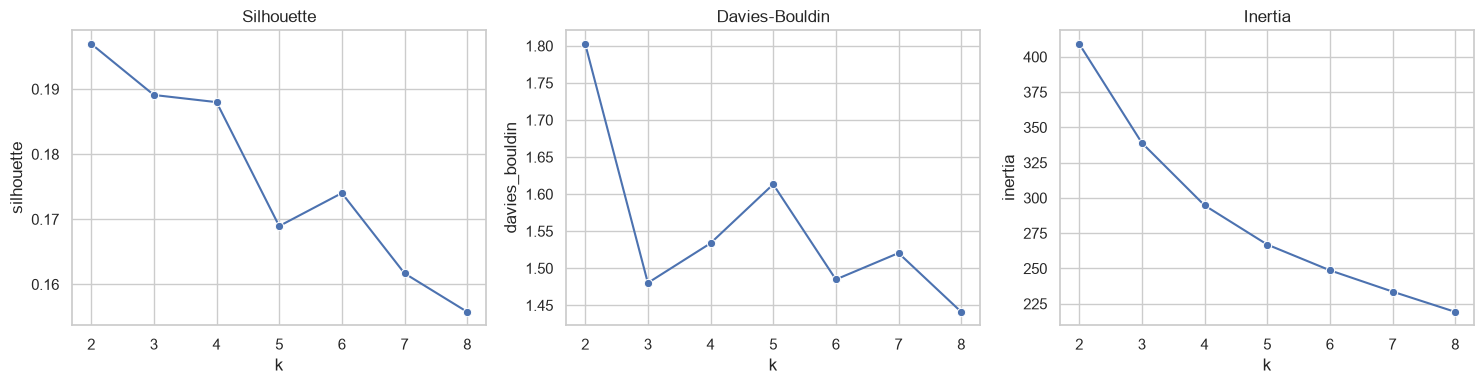

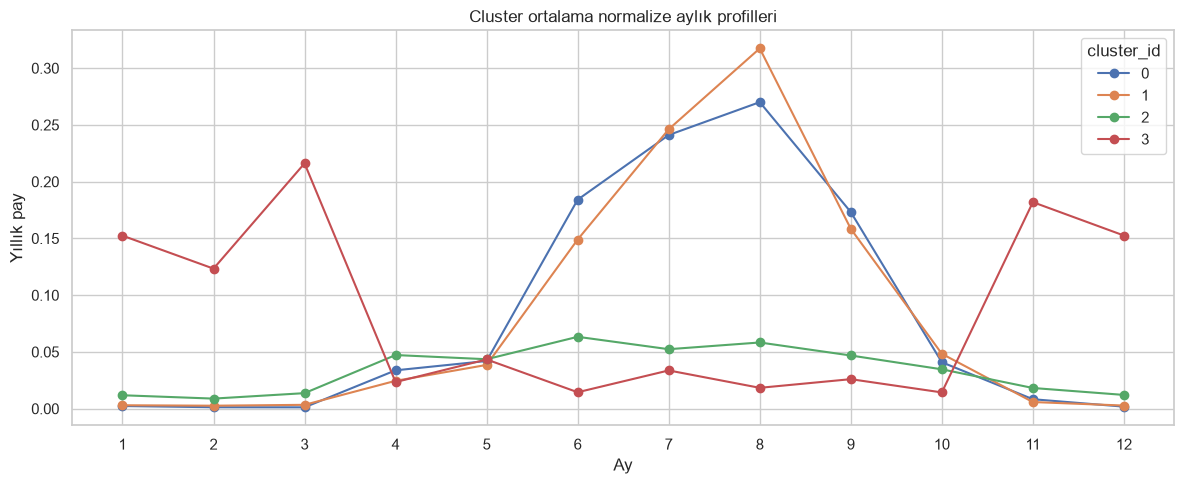

Optimum k=4; merkez öğrenim oteli=246/807


,k,silhouette,davies_bouldin,inertia,elbow_strength,selection_score
0,2,0.1969,1.8027,409.1897,0.0000,1.0000
1,3,0.1891,1.4802,339.0182,0.2028,2.4544
2,4,0.1880,1.5337,294.7384,0.2692,2.5265
3,5,0.1690,1.6132,266.9598,0.2488,1.7683
4,6,0.1740,1.4849,248.7106,0.1782,1.9843
5,7,0.1617,1.5205,233.6175,0.0910,1.2623
6,8,0.1558,1.4411,219.2457,0.0000,1.0000


,cluster_id,hotel_count,center_fit_hotel_count,annual_mean,peak_month,peak_intensity,season_length,summer_winter_ratio
0,0,110,110,801.758,7.582,0.309,4.655,459.375
1,1,412,83,17.830,7.517,0.635,2.396,13.032
2,2,236,45,40.869,2.831,0.130,2.174,4.176
3,3,49,8,7.143,5.245,0.735,1.959,0.727


In [5]:
cluster_source = monthly.loc[monthly["ds"].lt(pd.Timestamp("2025-01-01"))].copy()
cluster_source["month"] = cluster_source["ds"].dt.month
cluster_source["year"] = cluster_source["ds"].dt.year

month_profile = (
    cluster_source.groupby(["hotel_id", "month"])["occupied_nights"].mean()
    .unstack(fill_value=0)
    .reindex(index=hotel_ids, columns=range(1, 13), fill_value=0)
)
profile_total = month_profile.sum(axis=1)
normalized_profile = month_profile.div(profile_total.replace(0, np.nan), axis=0).fillna(0)
normalized_profile.columns = [f"month_{month:02d}" for month in normalized_profile.columns]
annual = cluster_source.groupby(["hotel_id", "year"])["occupied_nights"].sum().unstack(fill_value=0)
annual_mean = annual.mean(axis=1).reindex(hotel_ids, fill_value=0)
peak_value = month_profile.max(axis=1)

structural = pd.DataFrame(index=hotel_ids)
structural["annual_mean"] = annual_mean
structural["peak_month"] = month_profile.idxmax(axis=1).where(profile_total.gt(0), 0)
structural["peak_intensity"] = peak_value.div(profile_total.replace(0, np.nan)).fillna(0)
structural["coefficient_of_variation"] = month_profile.std(axis=1).div(month_profile.mean(axis=1).replace(0, np.nan)).fillna(0)
structural["season_length"] = month_profile.ge(peak_value.mul(0.20), axis=0).sum(axis=1).where(peak_value.gt(0), 0)
structural["summer_winter_ratio"] = month_profile[[6, 7, 8]].sum(axis=1).add(1).div(month_profile[[12, 1, 2]].sum(axis=1).add(1))

MIN_CLUSTER_SIGNAL = 24
fit_mask = annual_mean.ge(MIN_CLUSTER_SIGNAL)
model_structural = structural.copy()
model_structural["annual_mean"] = np.log1p(model_structural["annual_mean"])
model_structural["summer_winter_ratio"] = np.log1p(model_structural["summer_winter_ratio"])
for column in ["peak_intensity", "coefficient_of_variation"]:
    model_structural[column] = model_structural[column].clip(
        upper=model_structural.loc[fit_mask, column].quantile(0.99)
    )

profile_scaler = StandardScaler().fit(normalized_profile.loc[fit_mask])
structural_scaler = StandardScaler().fit(model_structural.loc[fit_mask])
profile_scaled = profile_scaler.transform(normalized_profile) / np.sqrt(normalized_profile.shape[1])
structural_scaled = structural_scaler.transform(model_structural) / np.sqrt(model_structural.shape[1])
cluster_matrix = np.hstack([profile_scaled, structural_scaled])
fit_matrix = cluster_matrix[fit_mask.to_numpy()]

cluster_rows = []
models_by_k = {}
for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE)
    labels = model.fit_predict(fit_matrix)
    models_by_k[k] = model
    cluster_rows.append({
        "k": k,
        "silhouette": silhouette_score(fit_matrix, labels),
        "davies_bouldin": davies_bouldin_score(fit_matrix, labels),
        "inertia": model.inertia_,
    })

cluster_diagnostics = pd.DataFrame(cluster_rows)
def minmax(series):
    span = series.max() - series.min()
    return (series - series.min()) / span if span else pd.Series(0.0, index=series.index)

inertia_norm = minmax(cluster_diagnostics["inertia"])
cluster_diagnostics["elbow_strength"] = np.linspace(inertia_norm.iloc[0], inertia_norm.iloc[-1], len(inertia_norm)) - inertia_norm
cluster_diagnostics["selection_score"] = (
    minmax(cluster_diagnostics["silhouette"])
    + minmax(-cluster_diagnostics["davies_bouldin"])
    + minmax(cluster_diagnostics["elbow_strength"])
)
optimal_k = int(cluster_diagnostics.loc[cluster_diagnostics["selection_score"].idxmax(), "k"])
cluster_model = models_by_k[optimal_k]
cluster_assignments = pd.DataFrame({
    "hotel_id": hotel_ids,
    "cluster_id": cluster_model.predict(cluster_matrix),
})
cluster_assignments["hotel_name"] = cluster_assignments["hotel_id"].map(hotel_lookup)
cluster_assignments["used_for_center_fit"] = fit_mask.to_numpy()
monthly = monthly.merge(cluster_assignments[["hotel_id", "cluster_id"]], on="hotel_id", how="left")

cluster_summary = (
    cluster_assignments.merge(structural.reset_index(), on="hotel_id")
    .groupby("cluster_id", as_index=False)
    .agg(
        hotel_count=("hotel_id", "nunique"),
        center_fit_hotel_count=("used_for_center_fit", "sum"),
        annual_mean=("annual_mean", "mean"),
        peak_month=("peak_month", "mean"),
        peak_intensity=("peak_intensity", "mean"),
        season_length=("season_length", "mean"),
        summer_winter_ratio=("summer_winter_ratio", "mean"),
    )
)

cluster_diagnostics.to_csv(OUTPUT_DIR / "cluster_diagnostics.csv", index=False, encoding="utf-8-sig")
cluster_assignments.to_csv(OUTPUT_DIR / "hotel_cluster_assignments.csv", index=False, encoding="utf-8-sig")
cluster_summary.to_csv(OUTPUT_DIR / "cluster_summary.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.lineplot(data=cluster_diagnostics, x="k", y="silhouette", marker="o", ax=axes[0])
sns.lineplot(data=cluster_diagnostics, x="k", y="davies_bouldin", marker="o", ax=axes[1])
sns.lineplot(data=cluster_diagnostics, x="k", y="inertia", marker="o", ax=axes[2])
axes[0].set_title("Silhouette")
axes[1].set_title("Davies-Bouldin")
axes[2].set_title("Inertia")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cluster_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()

profile_plot = normalized_profile.reset_index().merge(
    cluster_assignments[["hotel_id", "cluster_id"]], on="hotel_id"
).groupby("cluster_id").mean(numeric_only=True).drop(columns="hotel_id", errors="ignore").T
fig, ax = plt.subplots(figsize=(12, 5))
profile_plot.plot(marker="o", ax=ax)
ax.set(title="Cluster ortalama normalize aylık profilleri", xlabel="Ay", ylabel="Yıllık pay")
ax.set_xticks(range(12), range(1, 13))
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cluster_monthly_profiles.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"Optimum k={optimal_k}; merkez öğrenim oteli={fit_mask.sum()}/{len(fit_mask)}")
display(cluster_diagnostics.round(4), cluster_summary.round(3))

In [11]:
from pytorch_forecasting.data import GroupNormalizer


def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    error = np.abs(actual - predicted)
    nonzero = actual != 0
    denominator = np.abs(actual).sum()
    return {
        "MAE": float(mean_absolute_error(actual, predicted)),
        "RMSE": float(np.sqrt(mean_squared_error(actual, predicted))),
        "MAPE": float(np.mean(error[nonzero] / np.abs(actual[nonzero])) * 100) if nonzero.any() else np.nan,
        "WMAPE": float(error.sum() / denominator * 100) if denominator else np.nan,
        "R2": float(r2_score(actual, predicted)) if len(actual) > 1 and np.var(actual) > 0 else np.nan,
        "bias_pct": float((predicted.sum() - actual.sum()) / denominator * 100) if denominator else np.nan,
    }


def prepare_timeseries(frame):
    result = frame[["unique_id", "ds", "occupied_nights"]].copy()
    result["unique_id"] = result["unique_id"].astype(str)
    result["time_idx"] = (
        (result["ds"].dt.year - TRAIN_START.year) * 12
        + result["ds"].dt.month - TRAIN_START.month
    ).astype(int)
    result = result.rename(columns={"occupied_nights": "y"})
    return result.sort_values(["unique_id", "time_idx"])


def build_dataset(frame, template=None):
    data = prepare_timeseries(frame)
    if template is not None:
        return TimeSeriesDataSet.from_dataset(
            template,
            data,
            predict=True,
            stop_randomization=True,
        )
    return TimeSeriesDataSet(
        data,
        time_idx="time_idx",
        target="y",
        group_ids=["unique_id"],
        min_encoder_length=INPUT_SIZE,
        max_encoder_length=INPUT_SIZE,
        min_prediction_length=HORIZON,
        max_prediction_length=HORIZON,
        time_varying_unknown_reals=["y"],
        target_normalizer=GroupNormalizer(groups=["unique_id"]),
        add_target_scales=False,
        add_encoder_length=False,
        randomize_length=None,
    )


def fit_nhits(train_frame, max_epochs=20):
    dataset = build_dataset(train_frame)
    train_loader = dataset.to_dataloader(
        train=True,
        batch_size=64,
        num_workers=0,
    )
    model = NHiTS.from_dataset(
        dataset,
        learning_rate=1e-3,
        weight_decay=1e-3,
        loss=MAE(),
        hidden_size=64,
        n_blocks=[1, 1, 1],
        n_layers=2,
        dropout=0.1,
        log_interval=-1,
        reduce_on_plateau_patience=3,
    )
    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator="cpu",
        devices=1,
        gradient_clip_val=0.1,
        enable_checkpointing=False,
        enable_model_summary=False,
        logger=False,
        enable_progress_bar=True,
        deterministic=True,
    )
    trainer.fit(model, train_dataloaders=train_loader)
    return model, dataset


def predict_nhits(model, template, full_frame):
    prediction_dataset = build_dataset(full_frame, template=template)
    prediction = model.predict(
        prediction_dataset,
        mode="prediction",
        return_index=True,
        trainer_kwargs={"accelerator": "cpu", "devices": 1, "logger": False},
    )
    values = prediction.output.detach().cpu().numpy()
    index = prediction.index.reset_index(drop=True)
    rows = []
    for row_number, index_row in index.iterrows():
        start_idx = int(index_row["time_idx"])
        for step in range(values.shape[1]):
            rows.append({
                "unique_id": str(index_row["unique_id"]),
                "time_idx": start_idx + step,
                "prediction": max(float(values[row_number, step]), 0.0),
            })
    result = pd.DataFrame(rows)
    result["ds"] = TRAIN_START + result["time_idx"].map(lambda value: pd.offsets.MonthBegin(int(value)))
    return result


def seasonal_naive(frame, forecast_start, forecast_end):
    target = frame.loc[frame["ds"].between(forecast_start, forecast_end), ["unique_id", "ds"]].copy()
    history = frame[["unique_id", "ds", "occupied_nights"]].copy()
    history["ds"] = history["ds"] + pd.DateOffset(years=1)
    return target.merge(history, on=["unique_id", "ds"], how="left").rename(
        columns={"occupied_nights": "seasonal_naive"}
    )

## 3. Cluster bazlı N-HiTS ve 2026 testi

Her cluster içindeki oteller ayrı seri kimlikleri olarak tek global modelde birlikte öğrenilir. Model 24 aylık encoder ile sonraki 7 ayı doğrudan tahmin eder; recursive hata birikimi yoktur. Sonuçlar geçen yılın aynı ayını kullanan seasonal-naive benchmark ile karşılaştırılır.

In [14]:
if not (
    "prediction_parts" in globals()
    and len(prediction_parts) == optimal_k
    and "cluster_models" in globals()
    and len(cluster_models) == optimal_k
):
    cluster_models = {}
    cluster_datasets = {}
    prediction_parts = []

    for cluster_id in sorted(monthly["cluster_id"].unique()):
        cluster_frame = monthly.loc[monthly["cluster_id"].eq(cluster_id)].copy()
        train_frame = cluster_frame.loc[cluster_frame["ds"].le(TRAIN_END)]
        full_frame = cluster_frame.loc[cluster_frame["ds"].le(TEST_END)]
        hotel_count = train_frame["hotel_id"].nunique()
        print(f"Cluster {cluster_id}: {hotel_count} otel eğitiliyor...")

        model, dataset = fit_nhits(train_frame, max_epochs=10)
        predictions = predict_nhits(model, dataset, full_frame)
        predictions["cluster_id"] = cluster_id
        prediction_parts.append(predictions)
        cluster_models[cluster_id] = model
        cluster_datasets[cluster_id] = dataset
else:
    print("Eğitilmiş cluster modelleri ve tahminler yeniden kullanılıyor.")

nhits_predictions = pd.concat(prediction_parts, ignore_index=True)
nhits_predictions["ds"] = pd.to_datetime(nhits_predictions["ds"])
test_actual = monthly.loc[
    monthly["ds"].between(TEST_START, TEST_END),
    ["unique_id", "hotel_id", "hotel_name", "cluster_id", "ds", "occupied_nights"],
].copy()
naive_predictions = seasonal_naive(monthly, TEST_START, TEST_END)
naive_predictions["ds"] = pd.to_datetime(naive_predictions["ds"])
test_results = (
    test_actual.merge(
        nhits_predictions[["unique_id", "ds", "prediction"]],
        on=["unique_id", "ds"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        naive_predictions[["unique_id", "ds", "seasonal_naive"]],
        on=["unique_id", "ds"],
        how="left",
        validate="one_to_one",
    )
)
assert test_results["prediction"].notna().all()
assert test_results["seasonal_naive"].notna().all()
test_results.to_csv(OUTPUT_DIR / "hotel_monthly_predictions_2026.csv", index=False, encoding="utf-8-sig")

performance_rows = []
for cluster_id, group in test_results.groupby("cluster_id"):
    for model_name, prediction_column in [("NHiTS", "prediction"), ("SeasonalNaive", "seasonal_naive")]:
        performance_rows.append({
            "cluster_id": cluster_id,
            "hotel_count": group["hotel_id"].nunique(),
            "model": model_name,
            **regression_metrics(group["occupied_nights"], group[prediction_column]),
        })
cluster_performance = pd.DataFrame(performance_rows).sort_values(["cluster_id", "model"])
cluster_performance.to_csv(OUTPUT_DIR / "cluster_model_performance.csv", index=False, encoding="utf-8-sig")

overall_nhits = regression_metrics(test_results["occupied_nights"], test_results["prediction"])
overall_naive = regression_metrics(test_results["occupied_nights"], test_results["seasonal_naive"])
print("N-HiTS genel:", {key: round(value, 3) for key, value in overall_nhits.items()})
print("Seasonal naive:", {key: round(value, 3) for key, value in overall_naive.items()})
display(cluster_performance.round(3))

Eğitilmiş cluster modelleri ve tahminler yeniden kullanılıyor.
N-HiTS genel: {'MAE': 10.331, 'RMSE': 53.545, 'MAPE': 99.541, 'WMAPE': 77.648, 'R2': 0.586, 'bias_pct': -36.073}
Seasonal naive: {'MAE': 8.736, 'RMSE': 45.861, 'MAPE': 118.1, 'WMAPE': 65.664, 'R2': 0.696, 'bias_pct': -13.478}


,cluster_id,hotel_count,model,MAE,RMSE,MAPE,WMAPE,R2,bias_pct
0,0,110,NHiTS,50.007,129.526,112.989,77.182,0.560,-22.605
1,0,110,SeasonalNaive,39.343,111.343,116.733,60.723,0.675,-7.934
2,1,412,NHiTS,2.273,17.758,98.582,104.212,0.039,-82.891
3,1,412,SeasonalNaive,2.209,13.925,131.553,101.288,0.409,-21.371
4,2,236,NHiTS,7.739,37.574,90.460,69.335,0.628,-55.241
5,2,236,SeasonalNaive,7.342,32.402,111.327,65.775,0.723,-23.845
6,3,49,NHiTS,1.498,10.290,87.785,95.177,0.131,-80.471
7,3,49,SeasonalNaive,1.630,11.014,90.517,103.519,0.005,-79.815


## 4. Cluster ve otel performans analizleri

Top hacimli oteller gerçek 2026 Ocak-Temmuz toplamına göre sıralanır. "En iyi tahmin edilen" listesinde küçük paydalı yanıltıcı WMAPE sonuçlarını azaltmak için gerçek toplamı en az 50 occupied night olan oteller değerlendirilir.

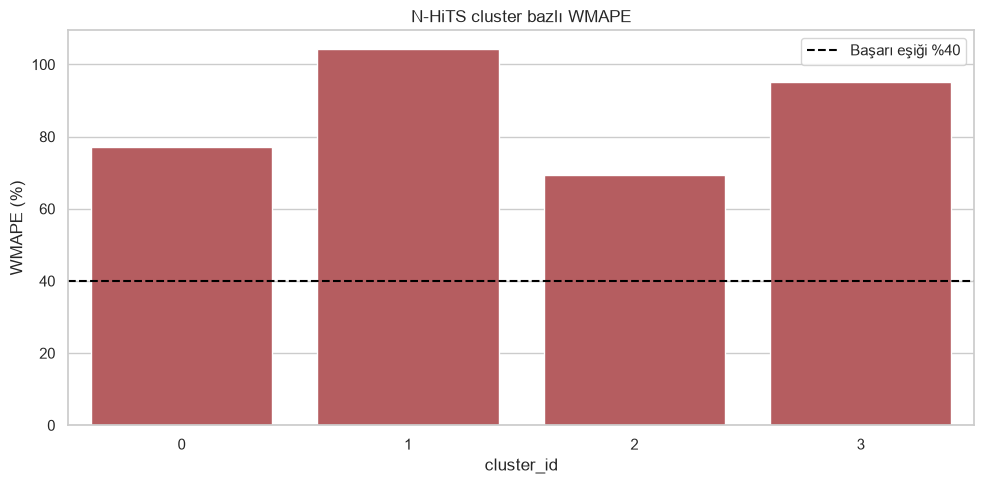

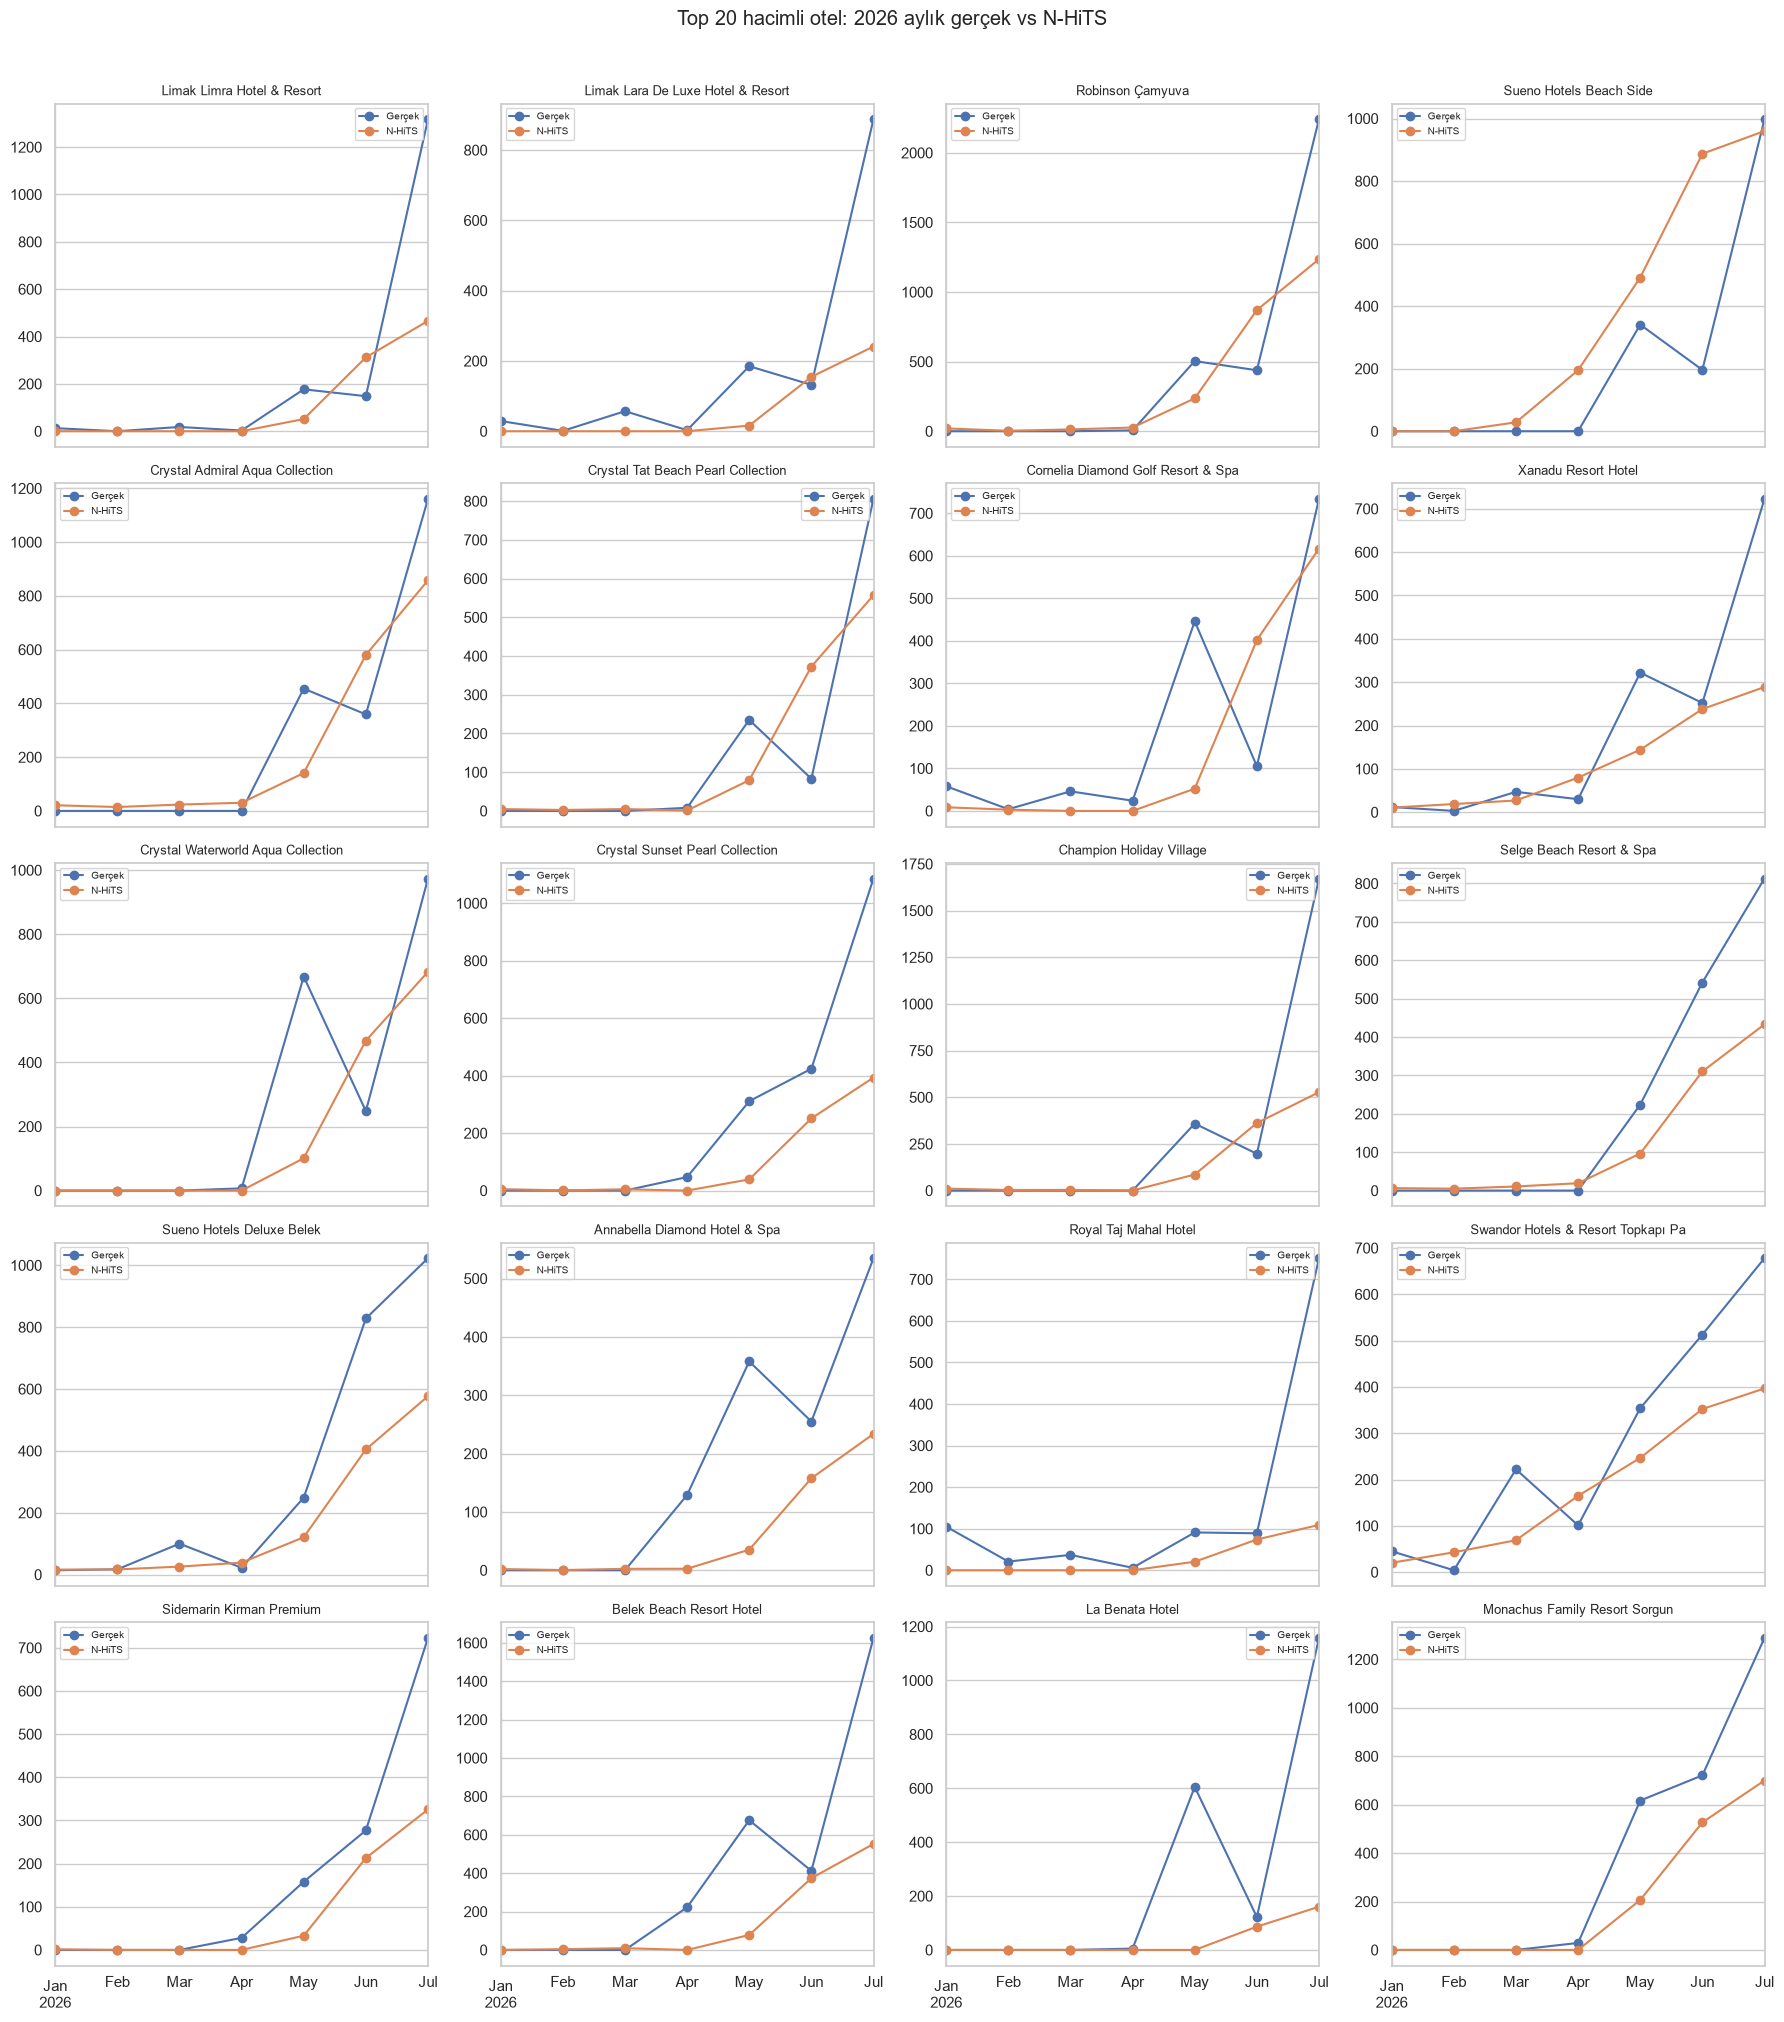

,hotel_id,hotel_name,cluster_id,actual_total,predicted_total,MAE,RMSE,MAPE,WMAPE,R2,bias_pct
0,456,Robinson Çamyuva,0,3190.0,2405.92,251.84,426.12,134.63,55.26,0.68,-24.58
1,181147,Belek Beach Resort Hotel,0,2936.0,1017.32,277.83,472.26,65.93,66.24,0.25,-65.35
2,201949,Monachus Family Resort Sorgun,2,2656.0,1432.97,174.72,281.39,59.80,46.05,0.64,-46.05
3,887,Sueno Hotels Deluxe Belek,0,2253.0,1199.57,155.85,239.18,44.79,48.42,0.63,-46.76
4,813,Champion Holiday Village,0,2228.0,992.68,228.59,449.19,76.05,71.82,0.37,-55.45
5,471,Crystal Admiral Aqua Collection,0,1975.0,1668.51,132.54,185.75,52.24,46.97,0.79,-15.52
6,1266,Swandor Hotels & Resort Topkapı Palace,2,1917.0,1292.19,118.56,144.49,180.09,43.29,0.62,-32.59
7,646,Crystal Waterworld Aqua Collection,0,1897.0,1251.90,155.00,254.85,75.86,57.19,0.52,-34.01
8,181836,La Benata Hotel,0,1890.0,246.82,234.74,441.18,78.84,86.94,-0.12,-86.94
9,647,Crystal Sunset Pearl Collection,0,1868.0,693.81,170.71,289.35,73.00,63.97,0.39,-62.86


,hotel_id,hotel_name,cluster_id,actual_total,predicted_total,MAE,RMSE,MAPE,WMAPE,R2,bias_pct
0,1400,Orange County Alanya,0,780.0,720.82,30.35,44.75,20.03,27.24,0.89,-7.59
1,907,Annabella Park Hotel,0,309.0,253.51,12.84,19.71,27.89,29.10,0.89,-17.96
2,808,Alder Resort Hotel,0,96.0,116.80,4.49,6.88,17.43,32.76,0.91,21.66
3,457,Robinson Nobilis,0,386.0,259.58,19.54,32.64,52.11,35.44,0.78,-32.75
4,1979,Bera Alanya Otel,0,237.0,188.78,12.47,23.50,25.71,36.84,0.78,-20.35
5,528,Blue Waters Club,0,284.0,343.98,15.91,26.37,88.73,39.22,0.77,21.12
6,3213,Club Marco Polo,0,561.0,427.90,33.44,53.82,41.42,41.73,0.79,-23.72
7,1266,Swandor Hotels & Resort Topkapı Palace,2,1917.0,1292.19,118.56,144.49,180.09,43.29,0.62,-32.59
8,3106,Leodikya Kirman Premium,0,363.0,214.68,22.65,39.76,57.12,43.68,0.70,-40.86
9,886,Kimeros Park Holiday Village,0,815.0,681.61,51.01,73.68,163.15,43.82,0.80,-16.37


In [15]:
def hotel_performance_table(frame):
    rows = []
    for keys, group in frame.groupby(["hotel_id", "hotel_name", "cluster_id"]):
        hotel_id, hotel_name, cluster_id = keys
        rows.append({
            "hotel_id": hotel_id,
            "hotel_name": hotel_name,
            "cluster_id": cluster_id,
            "actual_total": group["occupied_nights"].sum(),
            "predicted_total": group["prediction"].sum(),
            **regression_metrics(group["occupied_nights"], group["prediction"]),
        })
    return pd.DataFrame(rows)


hotel_performance = hotel_performance_table(test_results)
top_volume_hotels = hotel_performance.nlargest(20, "actual_total").reset_index(drop=True)
MIN_ACCURACY_VOLUME = 50
best_forecast_hotels = (
    hotel_performance.loc[hotel_performance["actual_total"].ge(MIN_ACCURACY_VOLUME)]
    .sort_values(["WMAPE", "MAE"])
    .head(20)
    .reset_index(drop=True)
)
top_volume_hotels.to_csv(OUTPUT_DIR / "top20_volume_hotels.csv", index=False, encoding="utf-8-sig")
best_forecast_hotels.to_csv(OUTPUT_DIR / "best20_forecast_hotels.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(10, 5))
nhits_cluster = cluster_performance.loc[cluster_performance["model"].eq("NHiTS")]
sns.barplot(data=nhits_cluster, x="cluster_id", y="WMAPE", color="#c44e52", ax=ax)
ax.axhline(SUCCESS_WMAPE, color="black", linestyle="--", label=f"Başarı eşiği %{SUCCESS_WMAPE:.0f}")
ax.set(title="N-HiTS cluster bazlı WMAPE", ylabel="WMAPE (%)")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cluster_wmape.png", dpi=160, bbox_inches="tight")
plt.show()

top_ids = top_volume_hotels["hotel_id"]
top_monthly = test_results.loc[test_results["hotel_id"].isin(top_ids)]
fig, axes = plt.subplots(5, 4, figsize=(18, 20), sharex=True)
for ax, (hotel_id, group) in zip(axes.flat, top_monthly.groupby("hotel_id", sort=False)):
    group.plot(x="ds", y=["occupied_nights", "prediction"], marker="o", ax=ax)
    ax.set_title(str(group["hotel_name"].iloc[0])[:34], fontsize=9)
    ax.set_xlabel("")
    ax.legend(["Gerçek", "N-HiTS"], fontsize=7)
fig.suptitle("Top 20 hacimli otel: 2026 aylık gerçek vs N-HiTS", y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "top20_volume_actual_vs_prediction.png", dpi=160, bbox_inches="tight")
plt.show()

display(top_volume_hotels.round(2))
display(best_forecast_hotels.round(2))

## 5. Antalya toplamı ve 2027 kalite kapısı

Başarı koşulu: N-HiTS WMAPE ≤ %40, R² ≥ 0.30 ve WMAPE'nin seasonal-naive benchmark'tan düşük olması. Bu üç koşul birlikte sağlanmadan 2027 tahmini üretilmez.

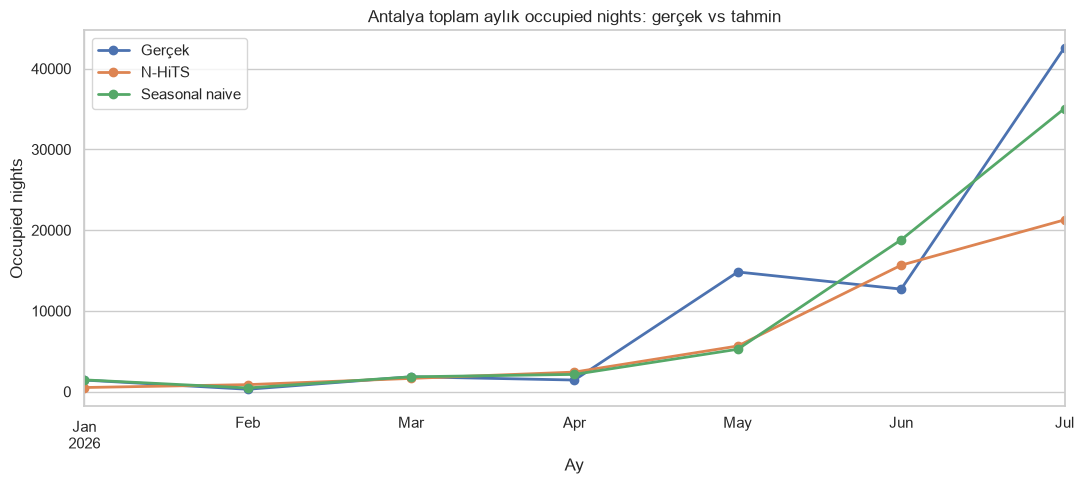

,ds,actual,nhits_prediction,seasonal_naive,difference,absolute_percentage_error
0,2026-01-01,1436.0,514.22,1461.0,-921.78,64.19
1,2026-02-01,298.0,872.73,462.0,574.73,192.86
2,2026-03-01,1846.0,1642.28,1839.0,-203.72,11.04
3,2026-04-01,1441.0,2425.77,2139.0,984.77,68.34
4,2026-05-01,14822.0,5656.43,5255.0,-9165.57,61.84
5,2026-06-01,12702.0,15660.87,18810.0,2958.87,23.29
6,2026-07-01,42613.0,21274.15,35062.0,-21338.85,50.08


,quality_gate_passed,nhits_WMAPE,nhits_R2,nhits_bias_pct,seasonal_naive_WMAPE,required_WMAPE,required_R2
0,False,77.648,0.586,-36.073,65.664,40.0,0.3


In [16]:
antalya_monthly = test_results.groupby("ds", as_index=False).agg(
    actual=("occupied_nights", "sum"),
    nhits_prediction=("prediction", "sum"),
    seasonal_naive=("seasonal_naive", "sum"),
)
antalya_monthly["difference"] = antalya_monthly["nhits_prediction"] - antalya_monthly["actual"]
antalya_monthly["absolute_percentage_error"] = np.where(
    antalya_monthly["actual"].ne(0),
    antalya_monthly["difference"].abs() / antalya_monthly["actual"] * 100,
    np.nan,
)
antalya_monthly.to_csv(OUTPUT_DIR / "monthly_antalya_actual_prediction.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(11, 5))
antalya_monthly.plot(
    x="ds",
    y=["actual", "nhits_prediction", "seasonal_naive"],
    marker="o",
    linewidth=2,
    ax=ax,
)
ax.set(title="Antalya toplam aylık occupied nights: gerçek vs tahmin", xlabel="Ay", ylabel="Occupied nights")
ax.legend(["Gerçek", "N-HiTS", "Seasonal naive"])
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "monthly_antalya_actual_vs_prediction.png", dpi=160, bbox_inches="tight")
plt.show()

quality_gate = bool(
    overall_nhits["WMAPE"] <= SUCCESS_WMAPE
    and overall_nhits["R2"] >= SUCCESS_R2
    and overall_nhits["WMAPE"] < overall_naive["WMAPE"]
)
quality_status = pd.DataFrame([{
    "quality_gate_passed": quality_gate,
    "nhits_WMAPE": overall_nhits["WMAPE"],
    "nhits_R2": overall_nhits["R2"],
    "nhits_bias_pct": overall_nhits["bias_pct"],
    "seasonal_naive_WMAPE": overall_naive["WMAPE"],
    "required_WMAPE": SUCCESS_WMAPE,
    "required_R2": SUCCESS_R2,
}])
quality_status.to_csv(OUTPUT_DIR / "quality_gate.csv", index=False, encoding="utf-8-sig")
display(antalya_monthly.round(2), quality_status.round(3))

In [17]:
forecast_2027_status = "SKIPPED_QUALITY_GATE"

if quality_gate:
    original_horizon = HORIZON
    future_months = pd.date_range(TEST_END + pd.offsets.MonthBegin(1), "2027-12-01", freq="MS")
    HORIZON = len(future_months)
    future = pd.MultiIndex.from_product(
        [hotel_ids, future_months], names=["hotel_id", "ds"]
    ).to_frame(index=False)
    future["occupied_nights"] = 0.0
    future["hotel_name"] = future["hotel_id"].map(hotel_lookup)
    future["unique_id"] = future["hotel_id"].astype(str)
    future = future.merge(cluster_assignments[["hotel_id", "cluster_id"]], on="hotel_id", how="left")
    history_and_future = pd.concat([monthly, future], ignore_index=True)

    forecast_parts = []
    try:
        for cluster_id in sorted(monthly["cluster_id"].unique()):
            train_frame = monthly.loc[
                monthly["cluster_id"].eq(cluster_id) & monthly["ds"].le(TEST_END)
            ]
            full_frame = history_and_future.loc[history_and_future["cluster_id"].eq(cluster_id)]
            model_2027, dataset_2027 = fit_nhits(train_frame, max_epochs=15)
            cluster_forecast = predict_nhits(model_2027, dataset_2027, full_frame)
            cluster_forecast["cluster_id"] = cluster_id
            forecast_parts.append(cluster_forecast)

        forecast_2027 = pd.concat(forecast_parts, ignore_index=True)
        forecast_2027["ds"] = pd.to_datetime(forecast_2027["ds"])
        forecast_2027 = forecast_2027.loc[forecast_2027["ds"].dt.year.eq(2027)]
        forecast_2027["hotel_id"] = forecast_2027["unique_id"].astype(int)
        forecast_2027["hotel_name"] = forecast_2027["hotel_id"].map(hotel_lookup)
        forecast_2027.to_csv(OUTPUT_DIR / "hotel_monthly_forecast_2027.csv", index=False, encoding="utf-8-sig")

        antalya_2027 = forecast_2027.groupby("ds", as_index=False)["prediction"].sum()
        antalya_2027.to_csv(OUTPUT_DIR / "monthly_antalya_forecast_2027.csv", index=False, encoding="utf-8-sig")
        fig, ax = plt.subplots(figsize=(11, 5))
        antalya_2027.plot(x="ds", y="prediction", marker="o", linewidth=2, ax=ax)
        ax.set(title="Antalya 2027 aylık N-HiTS tahmini", xlabel="Ay", ylabel="Occupied nights")
        fig.tight_layout()
        fig.savefig(OUTPUT_DIR / "monthly_antalya_forecast_2027.png", dpi=160, bbox_inches="tight")
        plt.show()
        forecast_2027_status = "GENERATED"
    finally:
        HORIZON = original_horizon
else:
    print(
        "2027 tahmini üretilmedi: N-HiTS kalite kapısını geçemedi. "
        f"WMAPE=%{overall_nhits['WMAPE']:.2f}, R²={overall_nhits['R2']:.3f}, "
        f"seasonal-naive WMAPE=%{overall_naive['WMAPE']:.2f}."
    )

report = f"""# Antalya Cluster Bazlı N-HiTS Sonuç Raporu

## Veri ve yöntem

- Aylık inhouse paneli: {monthly['hotel_id'].nunique()} otel, {len(monthly):,} otel-ay
- Eğitim: 2022-01 - 2025-12
- Test: 2026-01 - 2026-07
- Cluster sayısı: {optimal_k}; cluster merkezleri 2022-2024 verisiyle öğrenildi
- Model: cluster başına global N-HiTS, input size={INPUT_SIZE}, horizon={original_horizon if quality_gate else HORIZON}
- Benchmark: geçen yılın aynı ayı seasonal-naive

## Genel test sonucu

| Model | MAE | RMSE | MAPE | WMAPE | R² | Bias |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| N-HiTS | {overall_nhits['MAE']:.2f} | {overall_nhits['RMSE']:.2f} | {overall_nhits['MAPE']:.2f}% | {overall_nhits['WMAPE']:.2f}% | {overall_nhits['R2']:.3f} | {overall_nhits['bias_pct']:.2f}% |
| Seasonal naive | {overall_naive['MAE']:.2f} | {overall_naive['RMSE']:.2f} | {overall_naive['MAPE']:.2f}% | {overall_naive['WMAPE']:.2f}% | {overall_naive['R2']:.3f} | {overall_naive['bias_pct']:.2f}% |

## Karar

Kalite kapısı: **{'GEÇTİ' if quality_gate else 'GEÇMEDİ'}**. 2027 durumu: **{forecast_2027_status}**.

N-HiTS genel WMAPE hedefini geçemedi ve seasonal-naive benchmark'tan daha kötü kaldı. Özellikle düşük hacimli cluster'larda sıfır yoğunluğu, yalnız 48 aylık eğitim geçmişi ve 2026 yazındaki seviye değişimi performansı sınırladı.

## Önerilen sonraki deneyler

1. Otel başına ölçek-normalize hedef (`y / geçmiş yıllık toplam`) ve tahmin sonrası geri ölçekleme.
2. N-HiTS'e ay, otel aktifliği ve kapasite gibi bilinen/gerçek statik feature'lar ekleme.
3. Sıfır yoğun otelleri ayrı modelleme veya minimum hacim eşiği uygulama.
4. 2025 son 7 ayı validation yaparak epoch, hidden size ve loss tuning.
5. N-HiTS'i seasonal-naive ile residual/ensemble biçiminde birleştirme.
6. 2026 verisinin booking cut-off veya veri olgunluğu etkisini doğrulama.
"""
(OUTPUT_DIR / "summary_report.md").write_text(report, encoding="utf-8")

manifest = {
    "optimal_k": optimal_k,
    "hotel_count": int(monthly["hotel_id"].nunique()),
    "overall_nhits": overall_nhits,
    "overall_seasonal_naive": overall_naive,
    "quality_gate_passed": quality_gate,
    "forecast_2027_status": forecast_2027_status,
}
(OUTPUT_DIR / "run_manifest.json").write_text(
    json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8"
)
print(f"Rapor: {OUTPUT_DIR / 'summary_report.md'}")

2027 tahmini üretilmedi: N-HiTS kalite kapısını geçemedi. WMAPE=%77.65, R²=0.586, seasonal-naive WMAPE=%65.66.
Rapor: c:\Users\efe.turhan\Desktop\sales_forecasting\output_nhits\summary_report.md


## 6. Temizlenmiş veri + resmi tatil feature'lı N-HiTS v2

Bu bölüm önceki çalışmayı değiştirmez; bağımsız bir v2 deneyidir.

Temizlik kuralı:

- Bir otel-yılın toplam inhouse değeri 20'nin altındaysa o yıl güvenilmez sayılır ve eğitim serisine alınmaz.
- N-HiTS'in 24 aylık encoder'ı için 2025'te biten en az 3 ardışık güvenilir yıl şarttır.
- Test değerlendirmesinde 2026 Ocak-Temmuz toplamı en az 20 olan oteller kullanılır.
- Düşük hacimli oteller silinmez; kapsam raporunda ayrıca tutulur.
- Türkiye resmi tatili bulunan aylar `holiday_month=1`, diğer aylar `0` olur.

Not: Ani yüksek değerler otomatik silinmez. Antalya'da bayram ve yaz sezonu sıçramaları gerçek talep olabilir; kör winsorization önemli sinyali yok edebilir.

In [1]:
from pathlib import Path
import json
import warnings

import holidays
import lightning.pytorch as pl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE
from pytorch_forecasting.models import NHiTS

warnings.filterwarnings("ignore")
pl.seed_everything(42, workers=True)
sns.set_theme(style="whitegrid")

PROJECT_ROOT_V2 = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SOURCE_OUTPUT_V2 = PROJECT_ROOT_V2 / "output_nhits"
OUTPUT_DIR_V2 = PROJECT_ROOT_V2 / "output_nhits_cleaned"
OUTPUT_DIR_V2.mkdir(parents=True, exist_ok=True)

TRAIN_END_V2 = pd.Timestamp("2025-12-01")
TEST_START_V2 = pd.Timestamp("2026-01-01")
TEST_END_V2 = pd.Timestamp("2026-07-01")
MIN_ANNUAL_INHOUSE_V2 = 20
MIN_CONSECUTIVE_YEARS_V2 = 3
INPUT_SIZE_V2 = 24
HORIZON_V2 = 7

monthly_raw_v2 = pd.read_csv(
    SOURCE_OUTPUT_V2 / "monthly_hotel_inhouse.csv",
    parse_dates=["ds"],
    encoding="utf-8-sig",
)
cluster_assignments_v2 = pd.read_csv(
    SOURCE_OUTPUT_V2 / "hotel_cluster_assignments.csv",
    encoding="utf-8-sig",
)
monthly_raw_v2 = monthly_raw_v2.drop(columns="cluster_id", errors="ignore").merge(
    cluster_assignments_v2[["hotel_id", "cluster_id"]], on="hotel_id", how="left"
)
monthly_raw_v2["year"] = monthly_raw_v2["ds"].dt.year

tr_holidays_v2 = holidays.country_holidays("TR", years=range(2022, 2028))
holiday_months_v2 = {(day.year, day.month) for day in tr_holidays_v2}
monthly_raw_v2["holiday_month"] = [
    int((date.year, date.month) in holiday_months_v2) for date in monthly_raw_v2["ds"]
]
monthly_raw_v2["month_sin"] = np.sin(2 * np.pi * monthly_raw_v2["ds"].dt.month / 12)
monthly_raw_v2["month_cos"] = np.cos(2 * np.pi * monthly_raw_v2["ds"].dt.month / 12)

yearly_totals_v2 = (
    monthly_raw_v2.groupby(["hotel_id", "year"], as_index=False)["occupied_nights"]
    .sum()
    .rename(columns={"occupied_nights": "annual_inhouse"})
)
yearly_totals_v2["is_reliable_year"] = yearly_totals_v2["annual_inhouse"].ge(MIN_ANNUAL_INHOUSE_V2)

training_years_v2 = list(range(2022, 2026))
def trailing_reliable_start_v2(hotel_years):
    status = hotel_years.set_index("year")["is_reliable_year"].to_dict()
    if not status.get(2025, False):
        return None
    start_year = 2025
    while status.get(start_year - 1, False):
        start_year -= 1
    return start_year if 2025 - start_year + 1 >= MIN_CONSECUTIVE_YEARS_V2 else None

reliable_starts_v2 = (
    yearly_totals_v2.loc[yearly_totals_v2["year"].isin(training_years_v2)]
    .groupby("hotel_id")
    .apply(trailing_reliable_start_v2, include_groups=False)
    .dropna()
    .astype(int)
    .rename("reliable_start_year")
)
test_totals_v2 = yearly_totals_v2.loc[yearly_totals_v2["year"].eq(2026)].set_index("hotel_id")["annual_inhouse"]
eligible_hotels_v2 = reliable_starts_v2.index.intersection(
    test_totals_v2.loc[test_totals_v2.ge(MIN_ANNUAL_INHOUSE_V2)].index
)

clean_parts_v2 = []
for hotel_id in eligible_hotels_v2:
    start_year = int(reliable_starts_v2.loc[hotel_id])
    hotel_frame = monthly_raw_v2.loc[
        monthly_raw_v2["hotel_id"].eq(hotel_id)
        & monthly_raw_v2["ds"].between(pd.Timestamp(start_year, 1, 1), TEST_END_V2)
    ].copy()
    clean_parts_v2.append(hotel_frame)
monthly_clean_v2 = pd.concat(clean_parts_v2, ignore_index=True)
monthly_clean_v2["unique_id"] = monthly_clean_v2["hotel_id"].astype(str)

coverage_v2 = pd.DataFrame([{
    "all_hotels": monthly_raw_v2["hotel_id"].nunique(),
    "eligible_hotels": monthly_clean_v2["hotel_id"].nunique(),
    "excluded_hotels": monthly_raw_v2["hotel_id"].nunique() - monthly_clean_v2["hotel_id"].nunique(),
    "eligible_2026_actual": monthly_clean_v2.loc[monthly_clean_v2["ds"].between(TEST_START_V2, TEST_END_V2), "occupied_nights"].sum(),
    "all_2026_actual": monthly_raw_v2.loc[monthly_raw_v2["ds"].between(TEST_START_V2, TEST_END_V2), "occupied_nights"].sum(),
}])
coverage_v2["volume_coverage_pct"] = coverage_v2["eligible_2026_actual"] / coverage_v2["all_2026_actual"] * 100

yearly_totals_v2.to_csv(OUTPUT_DIR_V2 / "hotel_year_reliability.csv", index=False, encoding="utf-8-sig")
coverage_v2.to_csv(OUTPUT_DIR_V2 / "cleaning_coverage.csv", index=False, encoding="utf-8-sig")
monthly_clean_v2.to_csv(OUTPUT_DIR_V2 / "monthly_clean_with_holidays.csv", index=False, encoding="utf-8-sig")

print(f"PyTorch {torch.__version__}; cihaz={'cuda' if torch.cuda.is_available() else 'cpu'}")
print("Resmi tatil ayları:", sorted(holiday_months_v2))
display(coverage_v2.round(2))

Seed set to 42


PyTorch 2.13.0+cpu; cihaz=cpu
Resmi tatil ayları: [(2022, 1), (2022, 4), (2022, 5), (2022, 7), (2022, 8), (2022, 10), (2023, 1), (2023, 4), (2023, 5), (2023, 6), (2023, 7), (2023, 8), (2023, 10), (2024, 1), (2024, 4), (2024, 5), (2024, 6), (2024, 7), (2024, 8), (2024, 10), (2025, 1), (2025, 3), (2025, 4), (2025, 5), (2025, 6), (2025, 7), (2025, 8), (2025, 10), (2026, 1), (2026, 3), (2026, 4), (2026, 5), (2026, 7), (2026, 8), (2026, 10), (2027, 1), (2027, 3), (2027, 4), (2027, 5), (2027, 7), (2027, 8), (2027, 10)]


,all_hotels,eligible_hotels,excluded_hotels,eligible_2026_actual,all_2026_actual,volume_coverage_pct
0,807,108,699,61828.0,75158.0,82.26


In [2]:
def metrics_v2(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    error = np.abs(actual - predicted)
    nonzero = actual != 0
    denominator = np.abs(actual).sum()
    return {
        "MAE": float(mean_absolute_error(actual, predicted)),
        "RMSE": float(np.sqrt(mean_squared_error(actual, predicted))),
        "MAPE": float(np.mean(error[nonzero] / np.abs(actual[nonzero])) * 100) if nonzero.any() else np.nan,
        "WMAPE": float(error.sum() / denominator * 100) if denominator else np.nan,
        "R2": float(r2_score(actual, predicted)) if len(actual) > 1 and np.var(actual) > 0 else np.nan,
        "bias_pct": float((predicted.sum() - actual.sum()) / denominator * 100) if denominator else np.nan,
    }


def prepare_v2(frame):
    result = frame[[
        "unique_id", "ds", "occupied_nights", "holiday_month", "month_sin", "month_cos"
    ]].copy()
    result["unique_id"] = result["unique_id"].astype(str)
    result["time_idx"] = (
        (result["ds"].dt.year - 2022) * 12 + result["ds"].dt.month - 1
    ).astype(int)
    return result.rename(columns={"occupied_nights": "y"}).sort_values(["unique_id", "time_idx"])


def dataset_v2(frame, template=None):
    data = prepare_v2(frame)
    if template is not None:
        return TimeSeriesDataSet.from_dataset(
            template, data, predict=True, stop_randomization=True
        )
    return TimeSeriesDataSet(
        data,
        time_idx="time_idx",
        target="y",
        group_ids=["unique_id"],
        min_encoder_length=INPUT_SIZE_V2,
        max_encoder_length=INPUT_SIZE_V2,
        min_prediction_length=HORIZON_V2,
        max_prediction_length=HORIZON_V2,
        time_varying_known_reals=["holiday_month", "month_sin", "month_cos"],
        time_varying_unknown_reals=["y"],
        target_normalizer=GroupNormalizer(groups=["unique_id"]),
        add_target_scales=False,
        add_encoder_length=False,
        randomize_length=None,
    )


def fit_v2(train_frame, epochs=10):
    dataset = dataset_v2(train_frame)
    loader = dataset.to_dataloader(train=True, batch_size=64, num_workers=0)
    model = NHiTS.from_dataset(
        dataset,
        learning_rate=1e-3,
        weight_decay=1e-3,
        loss=MAE(),
        hidden_size=64,
        n_blocks=[1, 1, 1],
        n_layers=2,
        dropout=0.1,
        log_interval=-1,
        reduce_on_plateau_patience=3,
    )
    trainer = pl.Trainer(
        max_epochs=epochs,
        accelerator="cpu",
        devices=1,
        gradient_clip_val=0.1,
        enable_checkpointing=False,
        enable_model_summary=False,
        logger=False,
        enable_progress_bar=True,
        deterministic=True,
    )
    trainer.fit(model, train_dataloaders=loader)
    return model, dataset


def predict_v2(model, template, full_frame):
    prediction = model.predict(
        dataset_v2(full_frame, template=template),
        mode="prediction",
        return_index=True,
        trainer_kwargs={"accelerator": "cpu", "devices": 1, "logger": False},
    )
    values = prediction.output.detach().cpu().numpy()
    index = prediction.index.reset_index(drop=True)
    rows = []
    for row_number, index_row in index.iterrows():
        for step in range(values.shape[1]):
            time_idx = int(index_row["time_idx"]) + step
            rows.append({
                "unique_id": str(index_row["unique_id"]),
                "time_idx": time_idx,
                "prediction_v2": max(float(values[row_number, step]), 0.0),
            })
    result = pd.DataFrame(rows)
    result["ds"] = pd.to_datetime({
        "year": 2022 + result["time_idx"] // 12,
        "month": result["time_idx"] % 12 + 1,
        "day": 1,
    })
    return result


probe_ids_v2 = (
    monthly_clean_v2.loc[monthly_clean_v2["ds"].le(TRAIN_END_V2)]
    .groupby("hotel_id")["occupied_nights"].sum().nlargest(12).index
)
probe_train_v2 = monthly_clean_v2.loc[
    monthly_clean_v2["hotel_id"].isin(probe_ids_v2) & monthly_clean_v2["ds"].le(TRAIN_END_V2)
]
probe_full_v2 = monthly_clean_v2.loc[monthly_clean_v2["hotel_id"].isin(probe_ids_v2)]
probe_model_v2, probe_dataset_v2 = fit_v2(probe_train_v2, epochs=1)
probe_prediction_v2 = predict_v2(probe_model_v2, probe_dataset_v2, probe_full_v2)
assert len(probe_prediction_v2) == len(probe_ids_v2) * HORIZON_V2
assert probe_prediction_v2["prediction_v2"].ge(0).all()
print("Holiday feature'lı N-HiTS v2 smoke test başarılı:", probe_prediction_v2.shape)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Holiday feature'lı N-HiTS v2 smoke test başarılı: (84, 4)


In [4]:
expected_clusters_v2 = sorted(monthly_clean_v2["cluster_id"].unique())
if not (
    "prediction_parts_v2" in globals()
    and len(prediction_parts_v2) == len(expected_clusters_v2)
    and "models_v2" in globals()
    and len(models_v2) == len(expected_clusters_v2)
):
    models_v2 = {}
    datasets_v2 = {}
    prediction_parts_v2 = []

    for cluster_id in expected_clusters_v2:
        cluster_frame_v2 = monthly_clean_v2.loc[monthly_clean_v2["cluster_id"].eq(cluster_id)]
        train_frame_v2 = cluster_frame_v2.loc[cluster_frame_v2["ds"].le(TRAIN_END_V2)]
        print(f"V2 Cluster {cluster_id}: {train_frame_v2['hotel_id'].nunique()} güvenilir otel")
        model_v2, dataset_template_v2 = fit_v2(train_frame_v2, epochs=10)
        cluster_prediction_v2 = predict_v2(model_v2, dataset_template_v2, cluster_frame_v2)
        cluster_prediction_v2["cluster_id"] = cluster_id
        prediction_parts_v2.append(cluster_prediction_v2)
        models_v2[cluster_id] = model_v2
        datasets_v2[cluster_id] = dataset_template_v2
else:
    print("Eğitilmiş v2 modelleri ve tahminler yeniden kullanılıyor.")

predictions_v2 = pd.concat(prediction_parts_v2, ignore_index=True)
predictions_v2["unique_id"] = predictions_v2["unique_id"].astype(str)
test_v2 = monthly_clean_v2.loc[
    monthly_clean_v2["ds"].between(TEST_START_V2, TEST_END_V2),
    ["unique_id", "hotel_id", "hotel_name", "cluster_id", "ds", "occupied_nights", "holiday_month"],
].copy()
test_v2["unique_id"] = test_v2["unique_id"].astype(str)
test_v2 = test_v2.merge(
    predictions_v2[["unique_id", "ds", "prediction_v2"]],
    on=["unique_id", "ds"],
    how="left",
    validate="one_to_one",
)
assert test_v2["prediction_v2"].notna().all()

naive_source_v2 = monthly_raw_v2[["unique_id", "ds", "occupied_nights"]].copy()
naive_source_v2["unique_id"] = naive_source_v2["unique_id"].astype(str)
naive_source_v2["ds"] = naive_source_v2["ds"] + pd.DateOffset(years=1)
test_v2 = test_v2.merge(
    naive_source_v2.rename(columns={"occupied_nights": "seasonal_naive_v2"}),
    on=["unique_id", "ds"],
    how="left",
    validate="one_to_one",
)

old_predictions_v2 = pd.read_csv(
    SOURCE_OUTPUT_V2 / "hotel_monthly_predictions_2026.csv",
    parse_dates=["ds"],
    encoding="utf-8-sig",
)[["hotel_id", "ds", "prediction"]].rename(columns={"prediction": "old_nhits"})
test_v2 = test_v2.merge(
    old_predictions_v2, on=["hotel_id", "ds"], how="left", validate="one_to_one"
)
assert test_v2[["seasonal_naive_v2", "old_nhits"]].notna().all().all()

comparison_rows_v2 = []
for model_name_v2, prediction_column_v2 in [
    ("NHiTS_v2_clean_holiday", "prediction_v2"),
    ("NHiTS_v1_same_cohort", "old_nhits"),
    ("SeasonalNaive_same_cohort", "seasonal_naive_v2"),
]:
    comparison_rows_v2.append({
        "model": model_name_v2,
        "hotel_count": test_v2["hotel_id"].nunique(),
        **metrics_v2(test_v2["occupied_nights"], test_v2[prediction_column_v2]),
    })
comparison_v2 = pd.DataFrame(comparison_rows_v2).sort_values("WMAPE")

cluster_rows_v2 = []
for cluster_id, group_v2 in test_v2.groupby("cluster_id"):
    cluster_rows_v2.append({
        "cluster_id": cluster_id,
        "hotel_count": group_v2["hotel_id"].nunique(),
        **metrics_v2(group_v2["occupied_nights"], group_v2["prediction_v2"]),
    })
cluster_performance_v2 = pd.DataFrame(cluster_rows_v2).sort_values("cluster_id")

test_v2.to_csv(OUTPUT_DIR_V2 / "hotel_monthly_predictions_2026_cleaned.csv", index=False, encoding="utf-8-sig")
comparison_v2.to_csv(OUTPUT_DIR_V2 / "model_comparison_same_cohort.csv", index=False, encoding="utf-8-sig")
cluster_performance_v2.to_csv(OUTPUT_DIR_V2 / "cluster_performance_cleaned.csv", index=False, encoding="utf-8-sig")

display(comparison_v2.round(3), cluster_performance_v2.round(3))

Eğitilmiş v2 modelleri ve tahminler yeniden kullanılıyor.


,model,hotel_count,MAE,RMSE,MAPE,WMAPE,R2,bias_pct
2,SeasonalNaive_same_cohort,108,45.905,110.526,122.641,56.130,0.706,-15.553
0,NHiTS_v2_clean_holiday,108,48.949,122.450,131.616,59.853,0.640,-30.512
1,NHiTS_v1_same_cohort,108,52.504,136.766,99.656,64.200,0.550,-40.832


,cluster_id,hotel_count,MAE,RMSE,MAPE,WMAPE,R2,bias_pct
0,0,72,57.998,140.211,133.734,59.660,0.642,-28.658
1,1,17,17.687,60.043,103.979,75.984,0.340,-58.098
2,2,19,42.631,86.641,141.185,56.350,0.609,-31.950


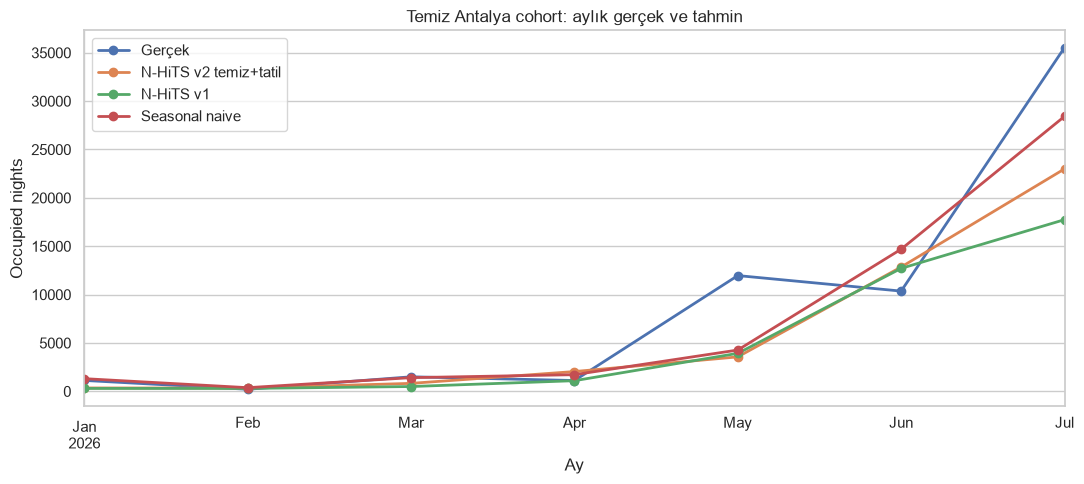

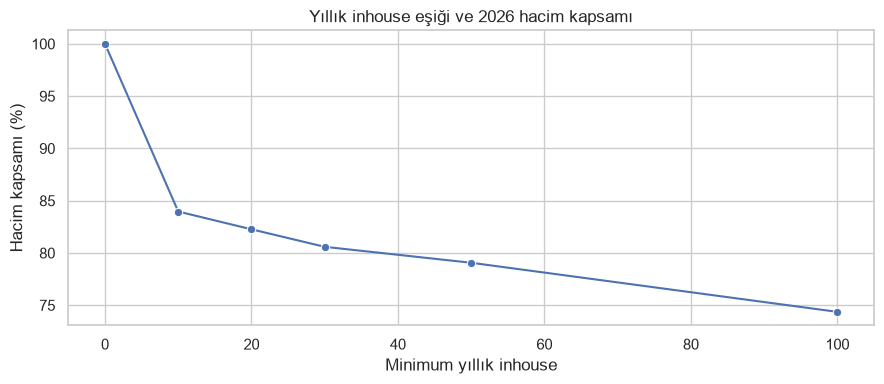

Şüpheli sıçrama sayısı: 183
V2 raporu: c:\Users\efe.turhan\Desktop\sales_forecasting\output_nhits_cleaned\summary_report.md


,annual_threshold,eligible_hotels,eligible_2026_volume,volume_coverage_pct
0,0,807,75158.0,100.00
1,10,134,63107.0,83.97
2,20,108,61828.0,82.26
3,30,96,60570.0,80.59
4,50,85,59424.0,79.07
5,100,68,55894.0,74.37


,ds,actual,nhits_v2,nhits_v1,seasonal_naive
0,2026-01-01,1127.0,349.32,300.03,1311.0
1,2026-02-01,214.0,336.93,299.85,379.0
2,2026-03-01,1503.0,823.73,497.90,1415.0
3,2026-04-01,1118.0,2045.12,1100.06,1722.0
4,2026-05-01,11966.0,3562.77,3928.21,4270.0
5,2026-06-01,10362.0,12850.54,12710.38,14694.0
6,2026-07-01,35538.0,22994.38,17745.93,28421.0


In [5]:
# Temizlik eşiği duyarlılığı: model eğitmeden kapsam etkisini gösterir.
sensitivity_rows_v2 = []
for threshold_v2 in [0, 10, 20, 30, 50, 100]:
    reliability_map_v2 = yearly_totals_v2.assign(
        reliable=yearly_totals_v2["annual_inhouse"].ge(threshold_v2)
    )
    eligible_count_v2 = 0
    eligible_volume_v2 = 0.0
    for hotel_id_v2, hotel_years_v2 in reliability_map_v2.groupby("hotel_id"):
        status_v2 = hotel_years_v2.set_index("year")["reliable"].to_dict()
        if all(status_v2.get(year_v2, False) for year_v2 in [2023, 2024, 2025, 2026]):
            eligible_count_v2 += 1
            eligible_volume_v2 += float(test_totals_v2.get(hotel_id_v2, 0))
    sensitivity_rows_v2.append({
        "annual_threshold": threshold_v2,
        "eligible_hotels": eligible_count_v2,
        "eligible_2026_volume": eligible_volume_v2,
        "volume_coverage_pct": eligible_volume_v2 / coverage_v2.loc[0, "all_2026_actual"] * 100,
    })
threshold_sensitivity_v2 = pd.DataFrame(sensitivity_rows_v2)
threshold_sensitivity_v2.to_csv(
    OUTPUT_DIR_V2 / "threshold_sensitivity.csv", index=False, encoding="utf-8-sig"
)

# Robust sıçrama listesi yalnız manuel inceleme içindir; otomatik veri silmez.
history_v2 = monthly_raw_v2.loc[monthly_raw_v2["ds"].between("2022-01-01", "2025-12-01")].copy()
history_v2["calendar_month"] = history_v2["ds"].dt.month
seasonal_stats_v2 = history_v2.groupby(["hotel_id", "calendar_month"])["occupied_nights"].agg(
    seasonal_median="median",
    seasonal_mad=lambda values: np.median(np.abs(values - np.median(values))),
).reset_index()
history_v2 = history_v2.merge(seasonal_stats_v2, on=["hotel_id", "calendar_month"], how="left")
history_v2["robust_z"] = np.where(
    history_v2["seasonal_mad"].gt(0),
    0.6745 * (history_v2["occupied_nights"] - history_v2["seasonal_median"]).abs() / history_v2["seasonal_mad"],
    np.nan,
)
suspected_spikes_v2 = history_v2.loc[
    history_v2["robust_z"].gt(6) & history_v2["occupied_nights"].ge(20),
    ["hotel_id", "hotel_name", "ds", "occupied_nights", "seasonal_median", "seasonal_mad", "robust_z", "holiday_month"],
].sort_values("robust_z", ascending=False)
suspected_spikes_v2.to_csv(
    OUTPUT_DIR_V2 / "suspected_monthly_spikes_for_review.csv", index=False, encoding="utf-8-sig"
)

antalya_v2 = test_v2.groupby("ds", as_index=False).agg(
    actual=("occupied_nights", "sum"),
    nhits_v2=("prediction_v2", "sum"),
    nhits_v1=("old_nhits", "sum"),
    seasonal_naive=("seasonal_naive_v2", "sum"),
)
antalya_v2.to_csv(OUTPUT_DIR_V2 / "monthly_antalya_comparison.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(11, 5))
antalya_v2.plot(
    x="ds", y=["actual", "nhits_v2", "nhits_v1", "seasonal_naive"],
    marker="o", linewidth=2, ax=ax,
)
ax.set(title="Temiz Antalya cohort: aylık gerçek ve tahmin", xlabel="Ay", ylabel="Occupied nights")
ax.legend(["Gerçek", "N-HiTS v2 temiz+tatil", "N-HiTS v1", "Seasonal naive"])
fig.tight_layout()
fig.savefig(OUTPUT_DIR_V2 / "monthly_antalya_cleaned_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=threshold_sensitivity_v2, x="annual_threshold", y="volume_coverage_pct", marker="o", ax=ax)
ax.set(title="Yıllık inhouse eşiği ve 2026 hacim kapsamı", xlabel="Minimum yıllık inhouse", ylabel="Hacim kapsamı (%)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR_V2 / "threshold_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()

best_v2 = comparison_v2.iloc[0]
new_v2 = comparison_v2.loc[comparison_v2["model"].eq("NHiTS_v2_clean_holiday")].iloc[0]
old_v2 = comparison_v2.loc[comparison_v2["model"].eq("NHiTS_v1_same_cohort")].iloc[0]
quality_gate_v2 = bool(new_v2["WMAPE"] <= 40 and new_v2["WMAPE"] < best_v2["WMAPE"] + 1e-9)

report_v2 = f"""# Temizlenmiş Antalya N-HiTS v2 Raporu

## Temizlik ve kapsam

- Yıllık minimum inhouse eşiği: {MIN_ANNUAL_INHOUSE_V2}
- En az ardışık güvenilir yıl: {MIN_CONSECUTIVE_YEARS_V2}
- Tüm Antalya otelleri: {int(coverage_v2.loc[0, 'all_hotels'])}
- Güvenilir cohort: {int(coverage_v2.loc[0, 'eligible_hotels'])} otel
- 2026 hacim kapsamı: %{coverage_v2.loc[0, 'volume_coverage_pct']:.2f}
- Resmi tatil içeren ay: `holiday_month=1`; diğer aylar `0`

## Aynı cohort üzerinde adil karşılaştırma

| Model | WMAPE | R² | Bias |
| --- | ---: | ---: | ---: |
| N-HiTS v2 temiz+tatil | {new_v2['WMAPE']:.2f}% | {new_v2['R2']:.3f} | {new_v2['bias_pct']:.2f}% |
| N-HiTS v1 | {old_v2['WMAPE']:.2f}% | {old_v2['R2']:.3f} | {old_v2['bias_pct']:.2f}% |
| Seasonal naive | {comparison_v2.loc[comparison_v2['model'].eq('SeasonalNaive_same_cohort'), 'WMAPE'].iloc[0]:.2f}% | {comparison_v2.loc[comparison_v2['model'].eq('SeasonalNaive_same_cohort'), 'R2'].iloc[0]:.3f} | {comparison_v2.loc[comparison_v2['model'].eq('SeasonalNaive_same_cohort'), 'bias_pct'].iloc[0]:.2f}% |

Temizlik ve tatil feature'ı eski N-HiTS'e göre WMAPE'yi {old_v2['WMAPE'] - new_v2['WMAPE']:.2f} puan iyileştirdi. Ancak seasonal-naive hâlâ daha iyi olduğu için 2027 kalite kapısı **GEÇMEDİ**.

## Veri kalitesi kararı

- `<20` otel-yıllar silinmek yerine güvenilmez olarak işaretlendi ve v2 eğitim serilerinden çıkarıldı.
- Şüpheli aylık sıçramalar `suspected_monthly_spikes_for_review.csv` dosyasına yazıldı; tatil/yaz talebi olabileceğinden otomatik silinmedi.
- Eşik etkisi `threshold_sensitivity.csv` ile izlenebilir. 20 eşiği hacmin %{coverage_v2.loc[0, 'volume_coverage_pct']:.2f}'sını koruyor.

## Sonraki en değerli deneyler

1. Temizlik ve holiday etkisini ayırmak için aynı temiz cohort'ta holiday'siz ablation modeli.
2. Otel kapasitesi veya geçmiş yıllık ölçek ile hedef normalizasyonu.
3. 2025 validation ile epoch, hidden size ve learning-rate seçimi.
4. Seasonal-naive residual tahmini veya ensemble.
5. Otelin açık/kapalı olduğu ayları belirleyen ayrı `is_active_month` alanı.
"""
(OUTPUT_DIR_V2 / "summary_report.md").write_text(report_v2, encoding="utf-8")

manifest_v2 = {
    "antalya_only": True,
    "annual_threshold": MIN_ANNUAL_INHOUSE_V2,
    "eligible_hotels": int(coverage_v2.loc[0, "eligible_hotels"]),
    "volume_coverage_pct": float(coverage_v2.loc[0, "volume_coverage_pct"]),
    "new_nhits_metrics": {key: float(new_v2[key]) for key in ["MAE", "RMSE", "MAPE", "WMAPE", "R2", "bias_pct"]},
    "quality_gate_passed": quality_gate_v2,
    "forecast_2027_status": "SKIPPED_QUALITY_GATE" if not quality_gate_v2 else "READY",
}
(OUTPUT_DIR_V2 / "run_manifest.json").write_text(
    json.dumps(manifest_v2, ensure_ascii=False, indent=2), encoding="utf-8"
)

print(f"Şüpheli sıçrama sayısı: {len(suspected_spikes_v2)}")
print(f"V2 raporu: {OUTPUT_DIR_V2 / 'summary_report.md'}")
display(threshold_sensitivity_v2.round(2), antalya_v2.round(2))

## 7. MAPE'ye göre en iyi 4 otelin gerçek-tahmin grafiği

Gerçek 2026 Ocak-Temmuz toplamı en az 50 occupied night olan temiz Antalya otelleri arasından MAPE'si en düşük dört otel seçilir. MAPE hesabında gerçek değeri sıfır olan aylar dışarıda bırakılır; görsellerde MAE, RMSE, MAPE, WMAPE, R² ve toplamlar gösterilir.

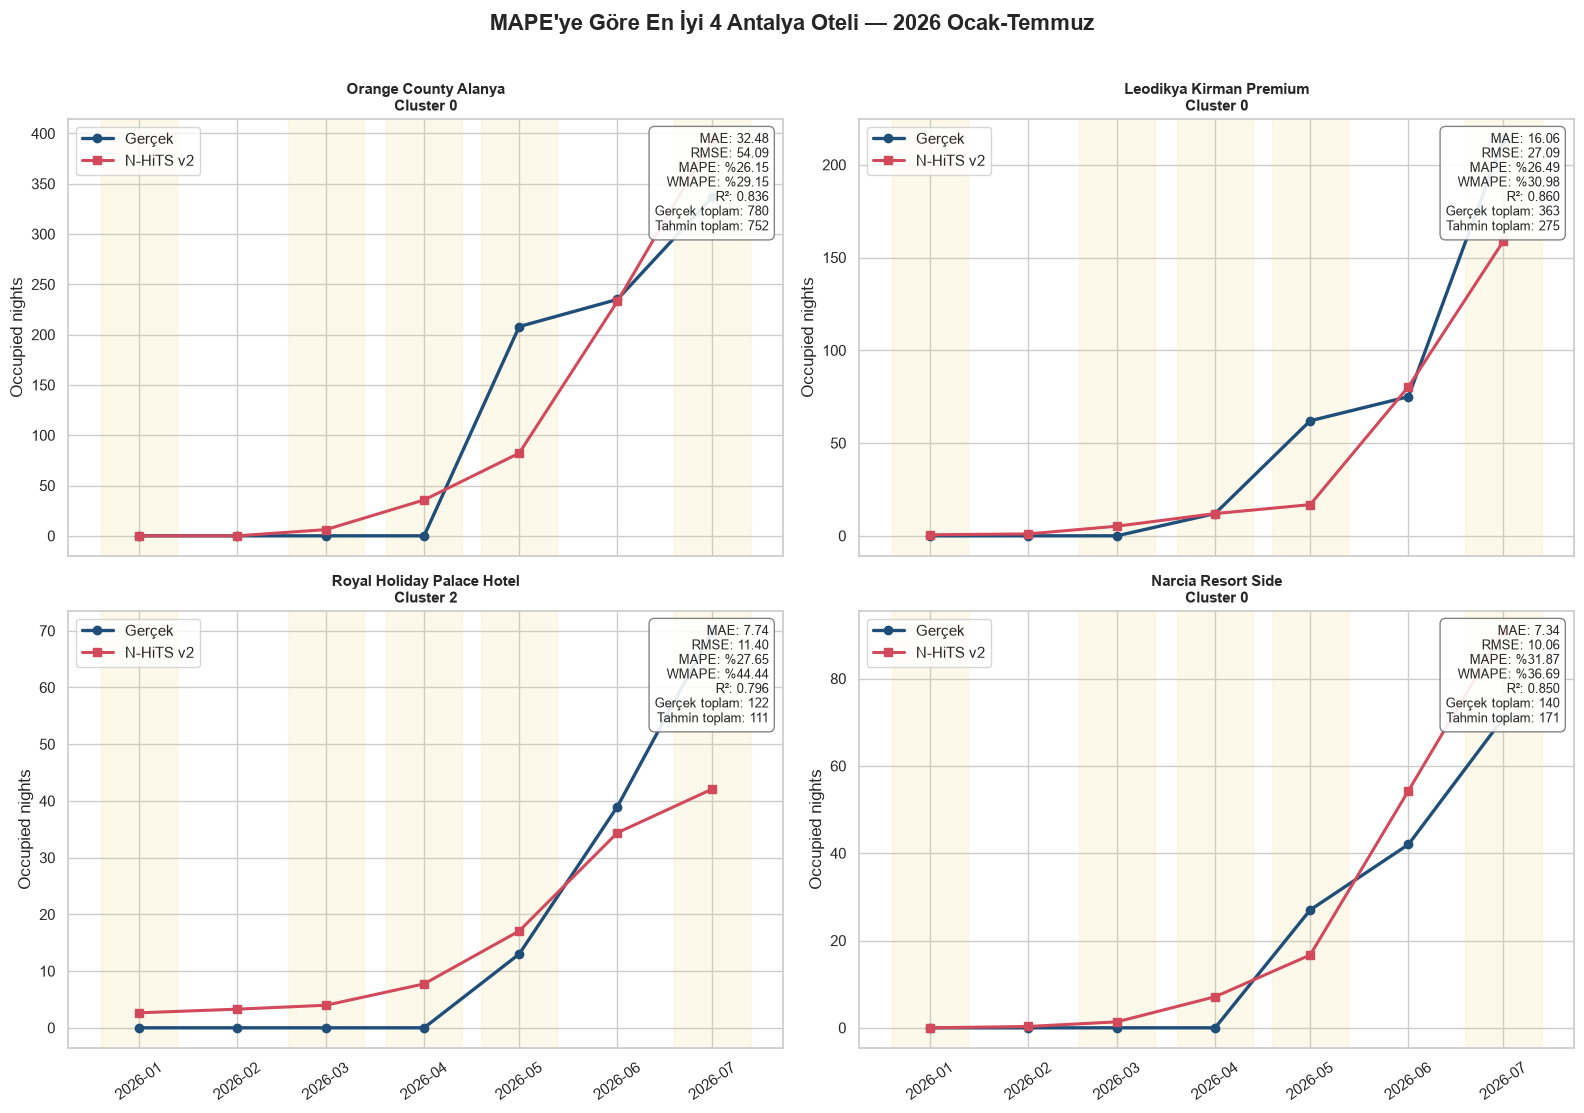

Grafik: c:\Users\efe.turhan\Desktop\sales_forecasting\output_nhits_cleaned\best4_mape_hotels_actual_vs_prediction.png
Metrikler: c:\Users\efe.turhan\Desktop\sales_forecasting\output_nhits_cleaned\best4_mape_hotels.csv


,hotel_id,hotel_name,cluster_id,actual_total,predicted_total,MAE,RMSE,MAPE,WMAPE,R2
0,1400,Orange County Alanya,0,780.0,751.765106,32.476096,54.091681,26.150650,29.145214,0.836337
1,3106,Leodikya Kirman Premium,0,363.0,274.809418,16.063171,27.087251,26.487905,30.975813,0.859613
2,1037,Royal Holiday Palace Hotel,2,122.0,111.229689,7.744690,11.395208,27.647868,44.436744,0.796368
3,924,Narcia Resort Side,0,140.0,170.720438,7.337223,10.061624,31.871151,36.686114,0.850305


In [ ]:
best4_rows_v2 = []
for keys_v2, hotel_group_v2 in test_v2.groupby(["hotel_id", "hotel_name", "cluster_id"]):
    actual_v2 = hotel_group_v2["occupied_nights"].to_numpy(dtype=float)
    predicted_v2 = hotel_group_v2["prediction_v2"].to_numpy(dtype=float)
    error_v2 = np.abs(actual_v2 - predicted_v2)
    nonzero_v2 = actual_v2 != 0
    actual_total_v2 = actual_v2.sum()

    best4_rows_v2.append({
        "hotel_id": keys_v2[0],
        "hotel_name": keys_v2[1],
        "cluster_id": keys_v2[2],
        "actual_total": actual_total_v2,
        "predicted_total": predicted_v2.sum(),
        "MAE": float(mean_absolute_error(actual_v2, predicted_v2)),
        "RMSE": float(np.sqrt(mean_squared_error(actual_v2, predicted_v2))),
        "MAPE": float(np.mean(error_v2[nonzero_v2] / np.abs(actual_v2[nonzero_v2])) * 100) if nonzero_v2.any() else np.nan,
        "WMAPE": float(error_v2.sum() / actual_total_v2 * 100) if actual_total_v2 else np.nan,
        "R2": float(r2_score(actual_v2, predicted_v2)) if len(actual_v2) > 1 and np.var(actual_v2) > 0 else np.nan,
    })

hotel_metrics_best4_v2 = pd.DataFrame(best4_rows_v2)
best4_mape_hotels_v2 = (
    hotel_metrics_best4_v2.loc[
        hotel_metrics_best4_v2["actual_total"].ge(50)
        & hotel_metrics_best4_v2["MAPE"].notna()
    ]
    .sort_values(["MAPE", "WMAPE"])
    .head(4)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True)
axes = axes.ravel()
for ax, hotel_row_v2 in zip(axes, best4_mape_hotels_v2.itertuples(index=False)):
    hotel_data_v2 = test_v2.loc[test_v2["hotel_id"].eq(hotel_row_v2.hotel_id)].sort_values("ds")
    ax.plot(
        hotel_data_v2["ds"], hotel_data_v2["occupied_nights"],
        color="#1f4e79", marker="o", linewidth=2.4, label="Gerçek",
    )
    ax.plot(
        hotel_data_v2["ds"], hotel_data_v2["prediction_v2"],
        color="#d1495b", marker="s", linewidth=2.2, label="N-HiTS v2",
    )
    holiday_rows_v2 = hotel_data_v2.loc[hotel_data_v2["holiday_month"].eq(1)]
    for holiday_date_v2 in holiday_rows_v2["ds"]:
        ax.axvspan(
            holiday_date_v2 - pd.Timedelta(days=12),
            holiday_date_v2 + pd.Timedelta(days=12),
            color="#f4d35e", alpha=0.13,
        )

    ax.set_title(f"{hotel_row_v2.hotel_name}\nCluster {hotel_row_v2.cluster_id}", fontsize=11, fontweight="bold")
    ax.set_ylabel("Occupied nights")
    ax.tick_params(axis="x", rotation=35)
    ax.legend(loc="upper left")
    metric_text_v2 = (
        f"MAE: {hotel_row_v2.MAE:.2f}\n"
        f"RMSE: {hotel_row_v2.RMSE:.2f}\n"
        f"MAPE: %{hotel_row_v2.MAPE:.2f}\n"
        f"WMAPE: %{hotel_row_v2.WMAPE:.2f}\n"
        f"R²: {hotel_row_v2.R2:.3f}\n"
        f"Gerçek toplam: {hotel_row_v2.actual_total:.0f}\n"
        f"Tahmin toplam: {hotel_row_v2.predicted_total:.0f}"
    )
    ax.text(
        0.98, 0.97, metric_text_v2,
        transform=ax.transAxes,
        ha="right", va="top", fontsize=9,
        bbox={"boxstyle": "round,pad=0.45", "facecolor": "white", "edgecolor": "#777777", "alpha": 0.9},
    )

fig.suptitle(
    "MAPE'ye Göre En İyi 4 Antalya Oteli — 2026 Ocak-Temmuz",
    fontsize=16, fontweight="bold", y=1.01,
)
fig.tight_layout()
plot_path_best4_v2 = OUTPUT_DIR_V2 / "best4_mape_hotels_actual_vs_prediction.png"
fig.savefig(plot_path_best4_v2, dpi=180, bbox_inches="tight")
plt.show()

best4_path_v2 = OUTPUT_DIR_V2 / "best4_mape_hotels.csv"
best4_mape_hotels_v2.to_csv(best4_path_v2, index=False, encoding="utf-8-sig")
print(f"Grafik: {plot_path_best4_v2}")
print(f"Metrikler: {best4_path_v2}")
display(best4_mape_hotels_v2.round(3))

## 8. Güncel otel sıralamaları: hacim, WMAPE ve MAPE

Model yeniden eğitilmez; kaydedilmiş en son 2026 Ocak-Temmuz tahminlerinden iki çıktı seti de yeniden hesaplanır.

- **Popüler 20:** gerçek toplam occupied nights en yüksek oteller.
- **En iyi 20 WMAPE:** toplam mutlak hatanın toplam gerçek hacme oranı en düşük oteller.
- **En iyi 20 MAPE:** gerçek değeri sıfır olmayan aylardaki ortalama mutlak yüzde hata en düşük oteller.
- WMAPE ve MAPE listelerinde küçük hacmin yanıltıcı etkisini azaltmak için gerçek toplam en az 50 occupied night olmalıdır.

In [9]:
def build_hotel_rankings(prediction_path, prediction_column, output_directory, label):
    predictions = pd.read_csv(prediction_path, parse_dates=["ds"], encoding="utf-8-sig")
    ranking_rows = []

    for keys, group in predictions.groupby(["hotel_id", "hotel_name", "cluster_id"]):
        actual = group["occupied_nights"].to_numpy(dtype=float)
        predicted = group[prediction_column].to_numpy(dtype=float)
        absolute_error = np.abs(actual - predicted)
        actual_total = actual.sum()
        nonzero = actual != 0
        weights = actual / actual_total if actual_total else np.zeros_like(actual)

        ranking_rows.append({
            "hotel_id": keys[0],
            "hotel_name": keys[1],
            "cluster_id": keys[2],
            "model": label,
            "actual_total": actual_total,
            "predicted_total": predicted.sum(),
            "MAE": float(mean_absolute_error(actual, predicted)),
            "WMAE": float(np.sum(weights * absolute_error)) if actual_total else np.nan,
            "RMSE": float(np.sqrt(mean_squared_error(actual, predicted))),
            "MAPE": float(np.mean(absolute_error[nonzero] / np.abs(actual[nonzero])) * 100) if nonzero.any() else np.nan,
            "WMAPE": float(absolute_error.sum() / actual_total * 100) if actual_total else np.nan,
            "R2": float(r2_score(actual, predicted)) if len(actual) > 1 and np.var(actual) > 0 else np.nan,
            "bias_pct": float((predicted.sum() - actual_total) / actual_total * 100) if actual_total else np.nan,
        })

    hotel_metrics = pd.DataFrame(ranking_rows)
    eligible = hotel_metrics.loc[hotel_metrics["actual_total"].ge(50)].copy()
    popular_20 = hotel_metrics.nlargest(20, "actual_total").reset_index(drop=True)
    best_wmape_20 = eligible.loc[eligible["WMAPE"].notna()].sort_values(
        ["WMAPE", "MAE"]
    ).head(20).reset_index(drop=True)
    best_mape_20 = eligible.loc[eligible["MAPE"].notna()].sort_values(
        ["MAPE", "WMAPE"]
    ).head(20).reset_index(drop=True)

    popular_20.to_csv(output_directory / "top20_popular_hotels_latest.csv", index=False, encoding="utf-8-sig")
    best_wmape_20.to_csv(output_directory / "best20_wmape_hotels_latest.csv", index=False, encoding="utf-8-sig")
    best_mape_20.to_csv(output_directory / "best20_mape_hotels_latest.csv", index=False, encoding="utf-8-sig")
    hotel_metrics.to_csv(output_directory / "all_hotel_metrics_latest.csv", index=False, encoding="utf-8-sig")

    return popular_20, best_wmape_20, best_mape_20


base_popular_20, base_best_wmape_20, base_best_mape_20 = build_hotel_rankings(
    PROJECT_ROOT_V2 / "output_nhits" / "hotel_monthly_predictions_2026.csv",
    "prediction",
    PROJECT_ROOT_V2 / "output_nhits",
    "NHiTS_v1",
)
clean_popular_20, clean_best_wmape_20, clean_best_mape_20 = build_hotel_rankings(
    OUTPUT_DIR_V2 / "hotel_monthly_predictions_2026_cleaned.csv",
    "prediction_v2",
    OUTPUT_DIR_V2,
    "NHiTS_v2_clean_holiday",
)

print("Model tahminleri değişmedi; sıralama dosyaları en son tahminlerden yenilendi.")
print("\nTEMİZLENMİŞ V2 — POPÜLER 20")
display(clean_popular_20.round(3))
print("\nTEMİZLENMİŞ V2 — EN İYİ 20 WMAPE")
display(clean_best_wmape_20.round(3))
print("\nTEMİZLENMİŞ V2 — EN İYİ 20 MAPE")
display(clean_best_mape_20.round(3))

Model tahminleri değişmedi; sıralama dosyaları en son tahminlerden yenilendi.

TEMİZLENMİŞ V2 — POPÜLER 20


,hotel_id,hotel_name,cluster_id,model,actual_total,predicted_total,MAE,WMAE,RMSE,MAPE,WMAPE,R2,bias_pct
0,456,Robinson Çamyuva,0,NHiTS_v2_clean_holiday,3190.0,2226.007,234.938,744.639,389.932,363.580,51.554,0.735,-30.219
1,181147,Belek Beach Resort Hotel,0,NHiTS_v2_clean_holiday,2936.0,1267.318,244.726,656.331,414.012,56.110,58.347,0.425,-56.835
2,887,Sueno Hotels Deluxe Belek,0,NHiTS_v2_clean_holiday,2253.0,1112.449,173.162,389.695,253.065,83.435,53.801,0.585,-50.624
3,813,Champion Holiday Village,0,NHiTS_v2_clean_holiday,2228.0,1189.159,211.131,791.238,388.765,72.660,66.334,0.531,-46.627
4,471,Crystal Admiral Aqua Collection,0,NHiTS_v2_clean_holiday,1975.0,1842.205,99.420,153.229,152.637,44.191,35.237,0.855,-6.724
5,1266,Swandor Hotels & Resort Topkapı Palace,2,NHiTS_v2_clean_holiday,1917.0,1406.001,85.937,124.821,107.477,140.399,31.380,0.790,-26.656
6,646,Crystal Waterworld Aqua Collection,0,NHiTS_v2_clean_holiday,1897.0,1346.613,144.091,327.644,239.375,209.199,53.170,0.574,-29.014
7,181836,La Benata Hotel,0,NHiTS_v2_clean_holiday,1890.0,562.772,210.147,691.548,380.172,141.106,77.832,0.165,-70.224
8,647,Crystal Sunset Pearl Collection,0,NHiTS_v2_clean_holiday,1868.0,814.576,155.374,436.210,258.427,53.062,58.224,0.513,-56.393
9,438,Limak Limra Hotel & Resort,0,NHiTS_v2_clean_holiday,1677.0,884.324,155.435,656.226,311.226,205.288,64.880,0.512,-47.267



TEMİZLENMİŞ V2 — EN İYİ 20 WMAPE


,hotel_id,hotel_name,cluster_id,model,actual_total,predicted_total,MAE,WMAE,RMSE,MAPE,WMAPE,R2,bias_pct
0,1400,Orange County Alanya,0,NHiTS_v2_clean_holiday,780.0,751.765,32.476,59.077,54.092,26.151,29.145,0.836,-3.620
1,457,Robinson Nobilis,0,NHiTS_v2_clean_holiday,386.0,343.223,16.608,32.331,22.634,178.166,30.119,0.895,-11.082
2,3106,Leodikya Kirman Premium,0,NHiTS_v2_clean_holiday,363.0,274.809,16.063,41.311,27.087,26.488,30.976,0.860,-24.295
3,1266,Swandor Hotels & Resort Topkapı Palace,2,NHiTS_v2_clean_holiday,1917.0,1406.001,85.937,124.821,107.477,140.399,31.380,0.790,-26.656
4,907,Annabella Park Hotel,0,NHiTS_v2_clean_holiday,309.0,235.256,13.936,27.240,20.707,35.105,31.569,0.874,-23.865
5,596,Robinson Pamfilya,0,NHiTS_v2_clean_holiday,402.0,288.822,18.802,42.359,27.268,69.241,32.741,0.877,-28.154
6,886,Kimeros Park Holiday Village,0,NHiTS_v2_clean_holiday,815.0,743.703,38.890,69.952,55.842,195.728,33.402,0.885,-8.748
7,528,Blue Waters Club,0,NHiTS_v2_clean_holiday,284.0,261.004,13.691,24.608,20.711,86.127,33.746,0.856,-8.097
8,10314,Club Boran Mare Beach,0,NHiTS_v2_clean_holiday,317.0,235.048,15.303,26.844,22.751,39.503,33.791,0.845,-25.852
9,471,Crystal Admiral Aqua Collection,0,NHiTS_v2_clean_holiday,1975.0,1842.205,99.420,153.229,152.637,44.191,35.237,0.855,-6.724



TEMİZLENMİŞ V2 — EN İYİ 20 MAPE


,hotel_id,hotel_name,cluster_id,model,actual_total,predicted_total,MAE,WMAE,RMSE,MAPE,WMAPE,R2,bias_pct
0,1400,Orange County Alanya,0,NHiTS_v2_clean_holiday,780.0,751.765,32.476,59.077,54.092,26.151,29.145,0.836,-3.620
1,3106,Leodikya Kirman Premium,0,NHiTS_v2_clean_holiday,363.0,274.809,16.063,41.311,27.087,26.488,30.976,0.860,-24.295
2,1037,Royal Holiday Palace Hotel,2,NHiTS_v2_clean_holiday,122.0,111.230,7.745,17.906,11.395,27.648,44.437,0.796,-8.828
3,924,Narcia Resort Side,0,NHiTS_v2_clean_holiday,140.0,170.720,7.337,15.801,10.062,31.871,36.686,0.850,21.943
4,180462,Riolavitas Resort & Spa Hotel,0,NHiTS_v2_clean_holiday,153.0,90.303,9.560,25.293,21.725,32.028,43.738,0.293,-40.979
5,3104,Sidemarin Kirman Premium,0,NHiTS_v2_clean_holiday,1186.0,707.843,71.855,221.198,128.325,34.818,42.410,0.728,-40.317
6,907,Annabella Park Hotel,0,NHiTS_v2_clean_holiday,309.0,235.256,13.936,27.240,20.707,35.105,31.569,0.874,-23.865
7,167762,Calyptus Kirman Premium,0,NHiTS_v2_clean_holiday,670.0,398.018,45.592,168.524,90.037,35.451,47.633,0.659,-40.594
8,436,Limak Atlantis De Luxe Hotel & Resort,0,NHiTS_v2_clean_holiday,1017.0,483.882,78.631,385.209,189.013,39.065,54.122,0.485,-52.421
9,3213,Club Marco Polo,0,NHiTS_v2_clean_holiday,561.0,370.957,32.312,90.055,55.446,39.495,40.317,0.774,-33.876


## 9. Nihai çıktı paketini sadeleştirme

Analiz tamamlandıktan sonra ara çıktılar tek klasörde altı teslim dosyasına indirgenir:

1. `hotel_monthly_predictions_2026.csv` — temiz cohort otel-ay gerçek ve tahminleri.
2. `hotel_rankings_top20.csv` — popüler, en iyi WMAPE ve en iyi MAPE listeleri tek dosyada.
3. `performance_summary.csv` — kapsam, model ve cluster performansı tek dosyada.
4. `monthly_antalya_comparison.csv` — Antalya aylık toplam karşılaştırması.
5. `analysis_overview.png` — Antalya toplamı ve eşik duyarlılığı.
6. `best4_mape_hotels.png` — en iyi dört MAPE otelinin grafiği.

Ara `output_nhits` klasörü ve diğer geçici çıktılar bu son hücrede kaldırılır. Notebook baştan çalıştırılırsa ara dosyalar yeniden üretilir ve sonunda tekrar sadeleştirilir.

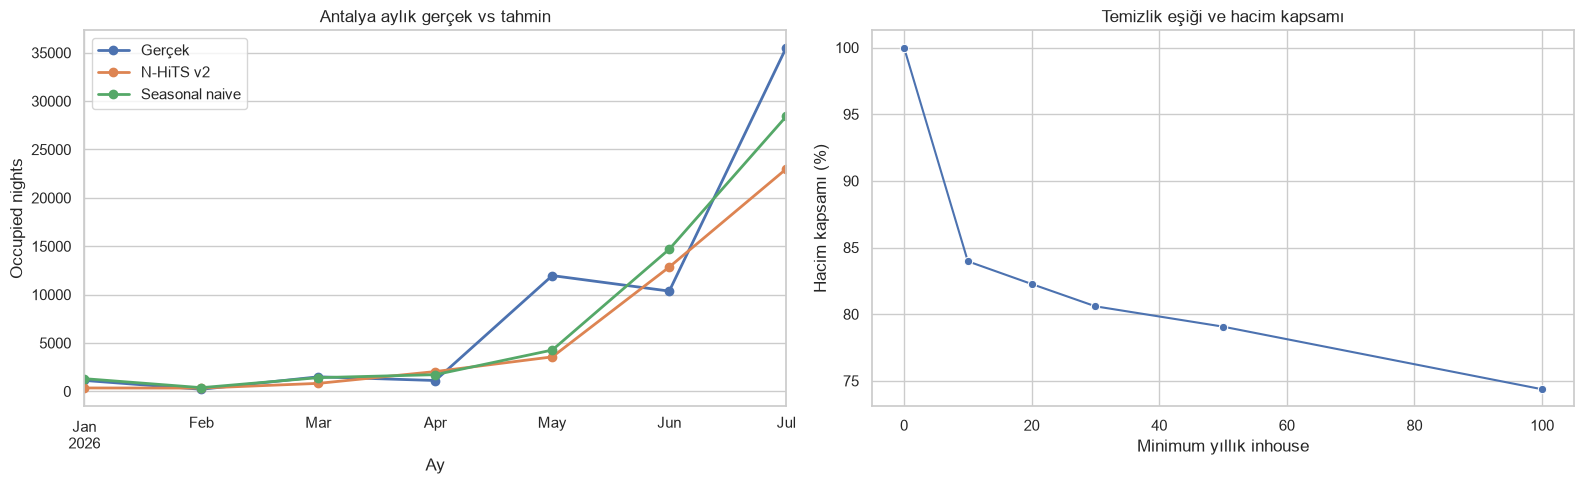

Nihai çıktı klasörü: c:\Users\efe.turhan\Desktop\sales_forecasting\output_nhits_cleaned
Dosya sayısı: 6
 - analysis_overview.png
 - best4_mape_hotels.png
 - hotel_monthly_predictions_2026.csv
 - hotel_rankings_top20.csv
 - monthly_antalya_comparison.csv
 - performance_summary.csv


In [10]:
import shutil

final_output_dir = PROJECT_ROOT_V2 / "output_nhits_cleaned"
base_output_dir = PROJECT_ROOT_V2 / "output_nhits"
final_output_dir.mkdir(parents=True, exist_ok=True)

# Üç sıralamayı tek CSV'de birleştir.
ranking_frames = []
for ranking_type, ranking_frame in [
    ("popular_top20", clean_popular_20),
    ("best_wmape_top20", clean_best_wmape_20),
    ("best_mape_top20", clean_best_mape_20),
]:
    ranked = ranking_frame.copy()
    ranked.insert(0, "ranking_type", ranking_type)
    ranked.insert(1, "rank", np.arange(1, len(ranked) + 1))
    ranking_frames.append(ranked)
rankings_final = pd.concat(ranking_frames, ignore_index=True)
rankings_final.to_csv(
    final_output_dir / "hotel_rankings_top20.csv", index=False, encoding="utf-8-sig"
)

# Kapsam, genel model ve cluster sonuçlarını tek şemada birleştir.
performance_rows_final = []
coverage_row = coverage_v2.iloc[0]
performance_rows_final.append({
    "scope": "coverage",
    "scope_id": "clean_cohort",
    "model": "NHiTS_v2_clean_holiday",
    "hotel_count": coverage_row["eligible_hotels"],
    "volume_coverage_pct": coverage_row["volume_coverage_pct"],
})
for row in comparison_v2.itertuples(index=False):
    performance_rows_final.append({
        "scope": "overall",
        "scope_id": "clean_cohort",
        "model": row.model,
        "hotel_count": row.hotel_count,
        "MAE": row.MAE,
        "RMSE": row.RMSE,
        "MAPE": row.MAPE,
        "WMAPE": row.WMAPE,
        "R2": row.R2,
        "bias_pct": row.bias_pct,
    })
for row in cluster_performance_v2.itertuples(index=False):
    performance_rows_final.append({
        "scope": "cluster",
        "scope_id": int(row.cluster_id),
        "model": "NHiTS_v2_clean_holiday",
        "hotel_count": row.hotel_count,
        "MAE": row.MAE,
        "RMSE": row.RMSE,
        "MAPE": row.MAPE,
        "WMAPE": row.WMAPE,
        "R2": row.R2,
        "bias_pct": row.bias_pct,
    })
pd.DataFrame(performance_rows_final).to_csv(
    final_output_dir / "performance_summary.csv", index=False, encoding="utf-8-sig"
)

# Ana veri tablolarını nihai kısa adlarla kaydet.
test_v2.to_csv(
    final_output_dir / "hotel_monthly_predictions_2026.csv", index=False, encoding="utf-8-sig"
)
antalya_v2.to_csv(
    final_output_dir / "monthly_antalya_comparison.csv", index=False, encoding="utf-8-sig"
)

# İki ana grafiği nihai adlarla oluştur/kopyala.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
antalya_v2.plot(
    x="ds", y=["actual", "nhits_v2", "seasonal_naive"],
    marker="o", linewidth=2, ax=axes[0],
)
axes[0].set_title("Antalya aylık gerçek vs tahmin")
axes[0].set_xlabel("Ay")
axes[0].set_ylabel("Occupied nights")
axes[0].legend(["Gerçek", "N-HiTS v2", "Seasonal naive"])
sns.lineplot(
    data=threshold_sensitivity_v2,
    x="annual_threshold", y="volume_coverage_pct", marker="o", ax=axes[1],
)
axes[1].set_title("Temizlik eşiği ve hacim kapsamı")
axes[1].set_xlabel("Minimum yıllık inhouse")
axes[1].set_ylabel("Hacim kapsamı (%)")
fig.tight_layout()
fig.savefig(final_output_dir / "analysis_overview.png", dpi=180, bbox_inches="tight")
plt.show()

shutil.copy2(
    final_output_dir / "best4_mape_hotels_actual_vs_prediction.png",
    final_output_dir / "best4_mape_hotels.png",
)

# Yalnızca altı nihai dosyayı bırak.
keep_files = {
    "hotel_monthly_predictions_2026.csv",
    "hotel_rankings_top20.csv",
    "performance_summary.csv",
    "monthly_antalya_comparison.csv",
    "analysis_overview.png",
    "best4_mape_hotels.png",
}
for path in final_output_dir.iterdir():
    if path.is_file() and path.name not in keep_files:
        path.unlink()
    elif path.is_dir():
        shutil.rmtree(path)

if base_output_dir.exists():
    shutil.rmtree(base_output_dir)

final_files = sorted(path.name for path in final_output_dir.iterdir() if path.is_file())
assert set(final_files) == keep_files
print(f"Nihai çıktı klasörü: {final_output_dir}")
print(f"Dosya sayısı: {len(final_files)}")
for file_name in final_files:
    print(" -", file_name)